In [1]:
import sys
sys.path.insert(0, '..')

In [ ]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [3]:
wid = 80
oversample = 4

nwavels = 20#13#6
npoly=3

n_zernikes = 20

optics = NICMOSFresnelOptics(512, wid, oversample, n_zernikes = n_zernikes, defocus=0., fnumber=80.)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"


# data = np.load("spectrum_iterative.npz", allow_pickle=True)
# weights = data["weights"]
# params = data["params"][()]

# weights_downsampled = ipx.interp1d(np.linspace(0,1,nwavels), np.linspace(0,1,weights.shape[0]), weights)

vects = np.load("../data/iterative_spectrum_basis_F160W.npy")[:,:npoly]

print(vects.shape)

assert vects.shape == (nwavels, npoly)


spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

ddir = "../data/MAST_2024-09-23T06_53_22.463Z/HST/"

files = """
na2a04mcq_cal.fits
na2a04mdq_cal.fits
na2a04mhq_cal.fits
na2a04miq_cal.fits
na2a04mmq_cal.fits
na2a04mnq_cal.fits
na2a04mrq_cal.fits
na2a04msq_cal.fits
na2a04mwq_cal.fits
na2a04mxq_cal.fits
na2a04n1q_cal.fits
na2a04n2q_cal.fits
na2a04n6q_cal.fits
na2a04n7q_cal.fits
na2a04nbq_cal.fits
na2a04ncq_cal.fits
na2a04nfq_cal.fits
na2a04ngq_cal.fits""".split()[:8]

exposures_single = [
    exposure_from_file(ddir + f, SinglePointFit(spectrum_basis, "F160W", precombined=False), crop=wid) for f in files
]


W0804 13:29:54.240754 2353847 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


(20, 3)
Version 4.4.1
158 88
Version 4.4.1
158 88
Version 4.4.1
195 88
Version 4.4.1
195 88
Version 4.4.1
195 125
Version 4.4.1
195 125
Version 4.4.1
158 125
Version 4.4.1
158 125


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)
/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This

In [4]:
vects.shape

(20, 3)

In [5]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

54701.03510048
N581
F160W
4.983496
54701.03526252
N581
F160W
4.983496
54701.03636209
N581
F160W
4.983496
54701.03652409
N581
F160W
4.983496
54701.03762363
N581
F160W
4.983496
54701.03778567
N581
F160W
4.983496
54701.0388852
N581
F160W
4.983496
54701.03904724
N581
F160W
4.983496


In [6]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "fnumber": 79.68,
    "quadrature": {},
}



for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))/0.3#*0.6
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample
    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = 0.


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

6.706039641338133
6.759596059935098
6.971720470993598
6.8633101192474095
8.945577304778718
9.465101088559404
4.283052858680761
4.38895511796606


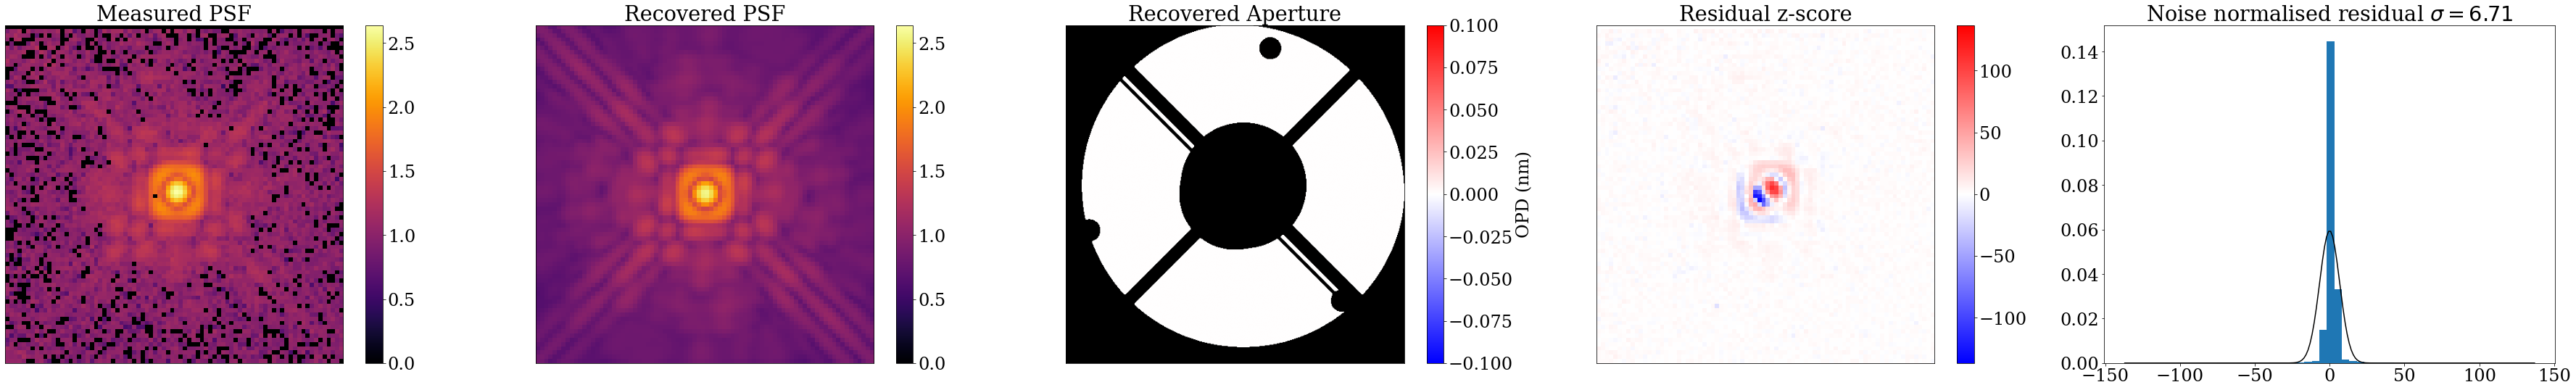

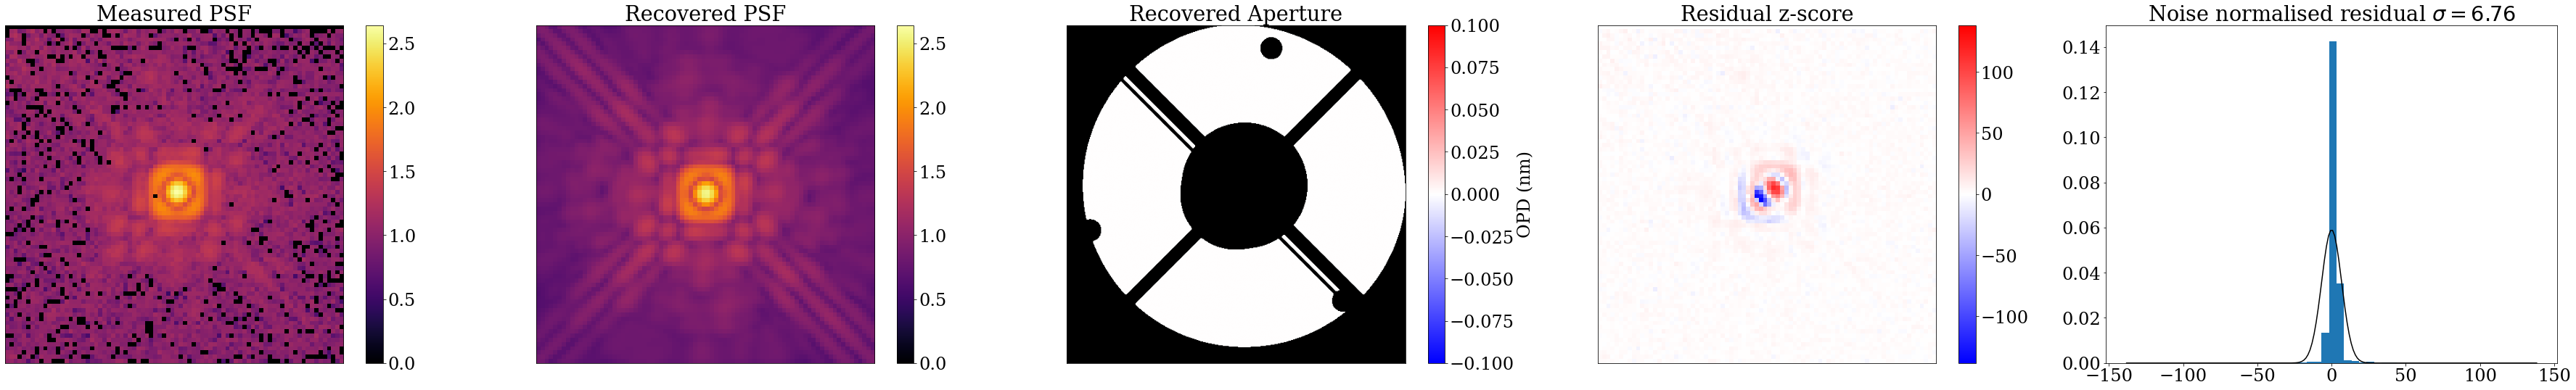

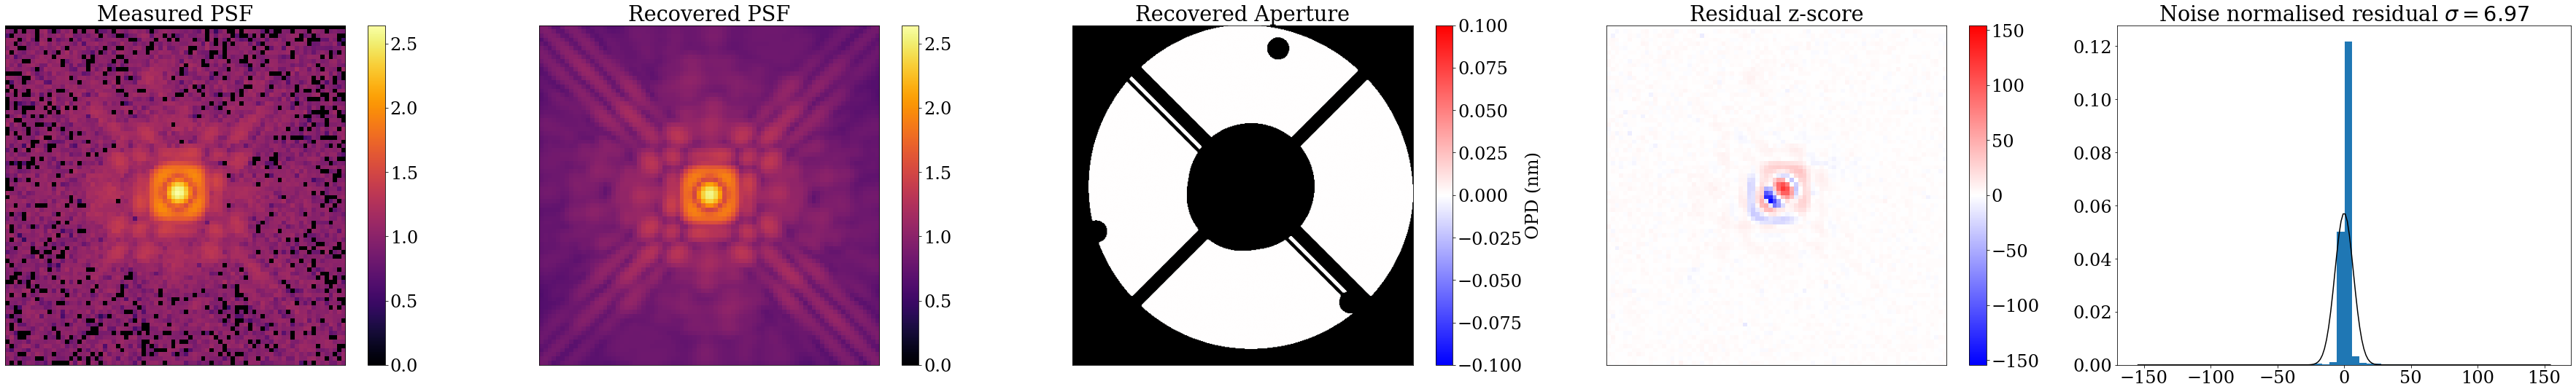

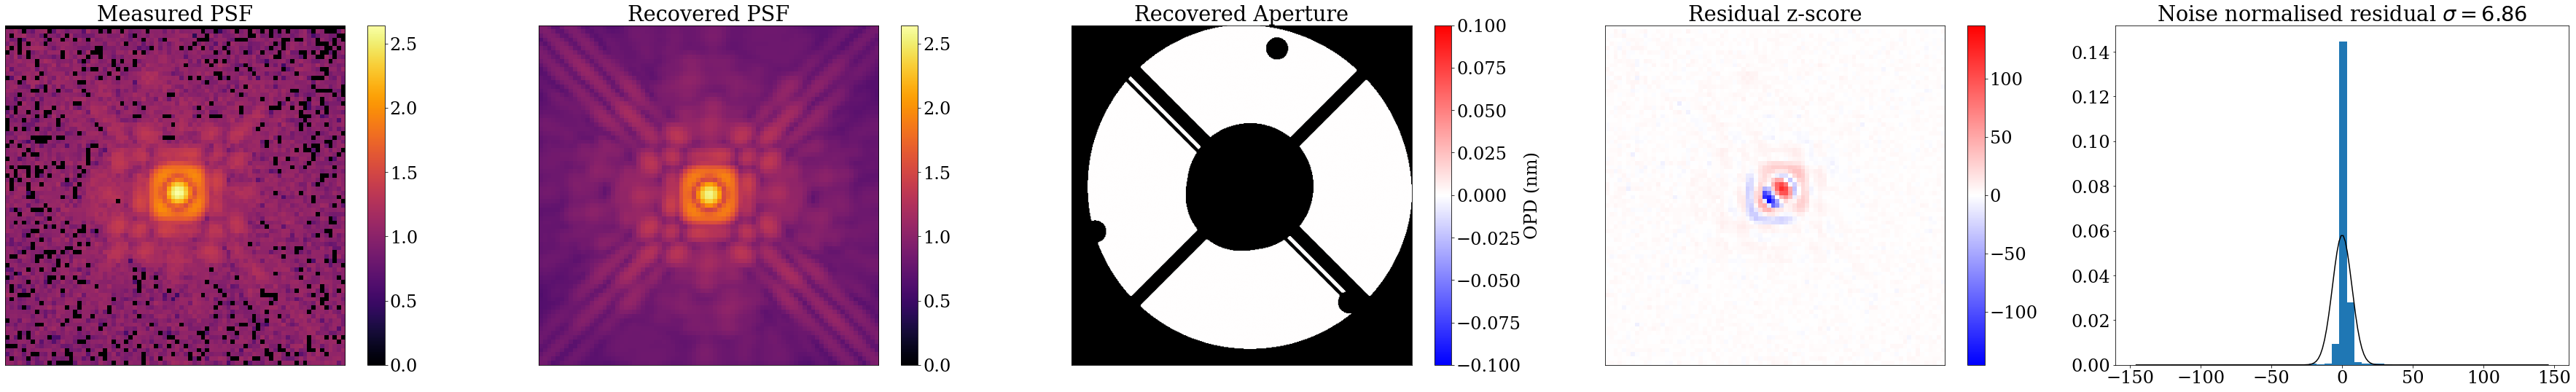

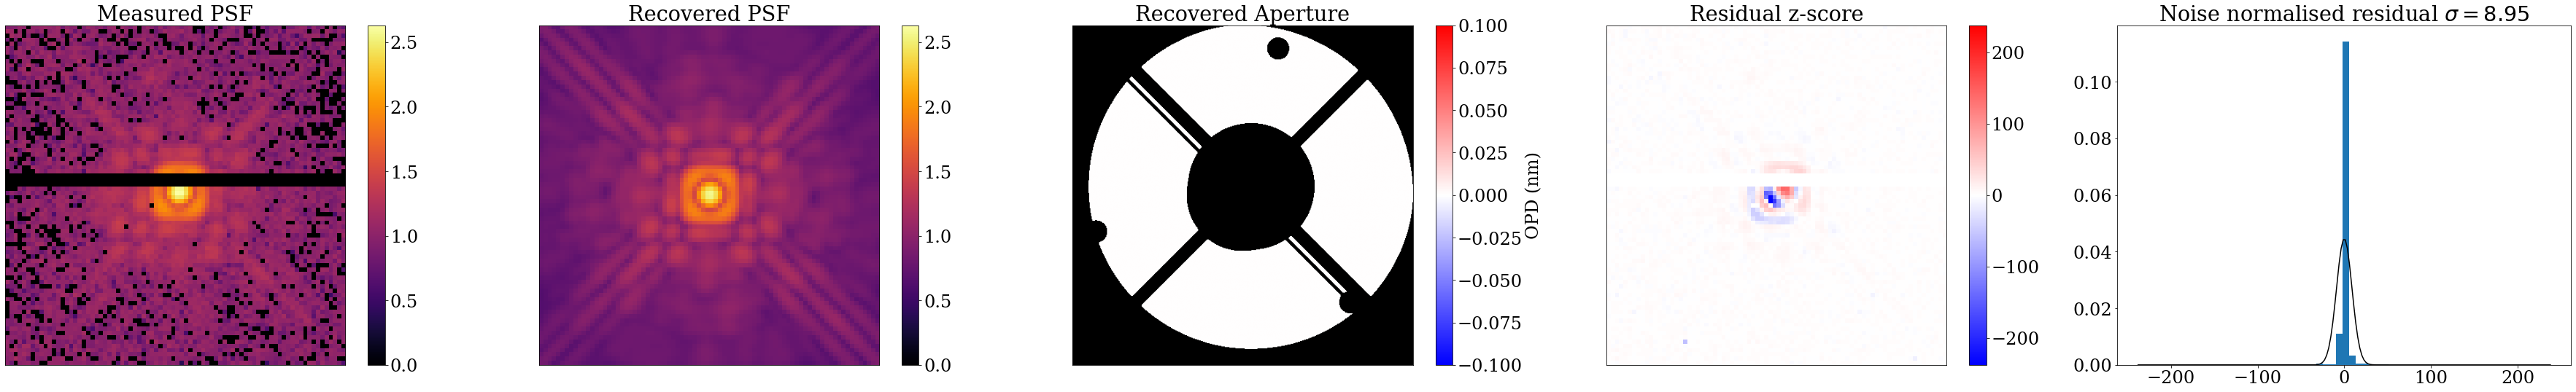

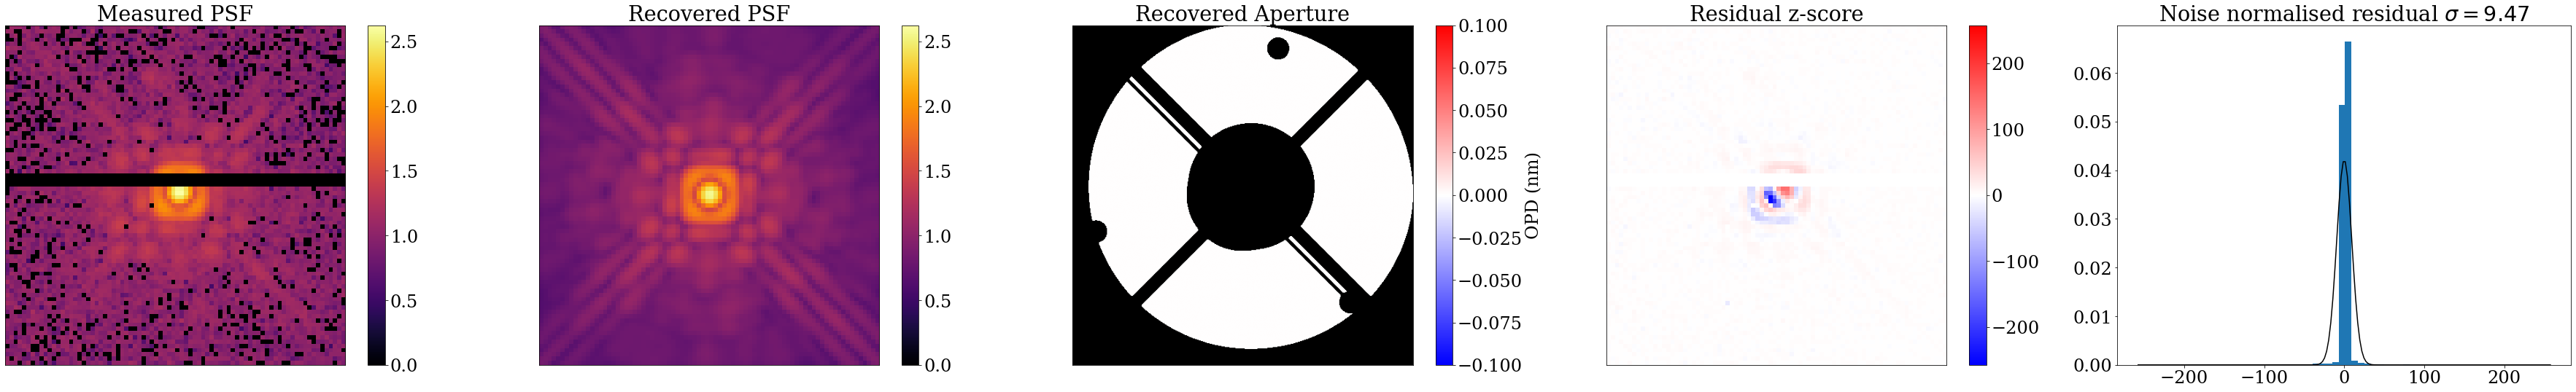

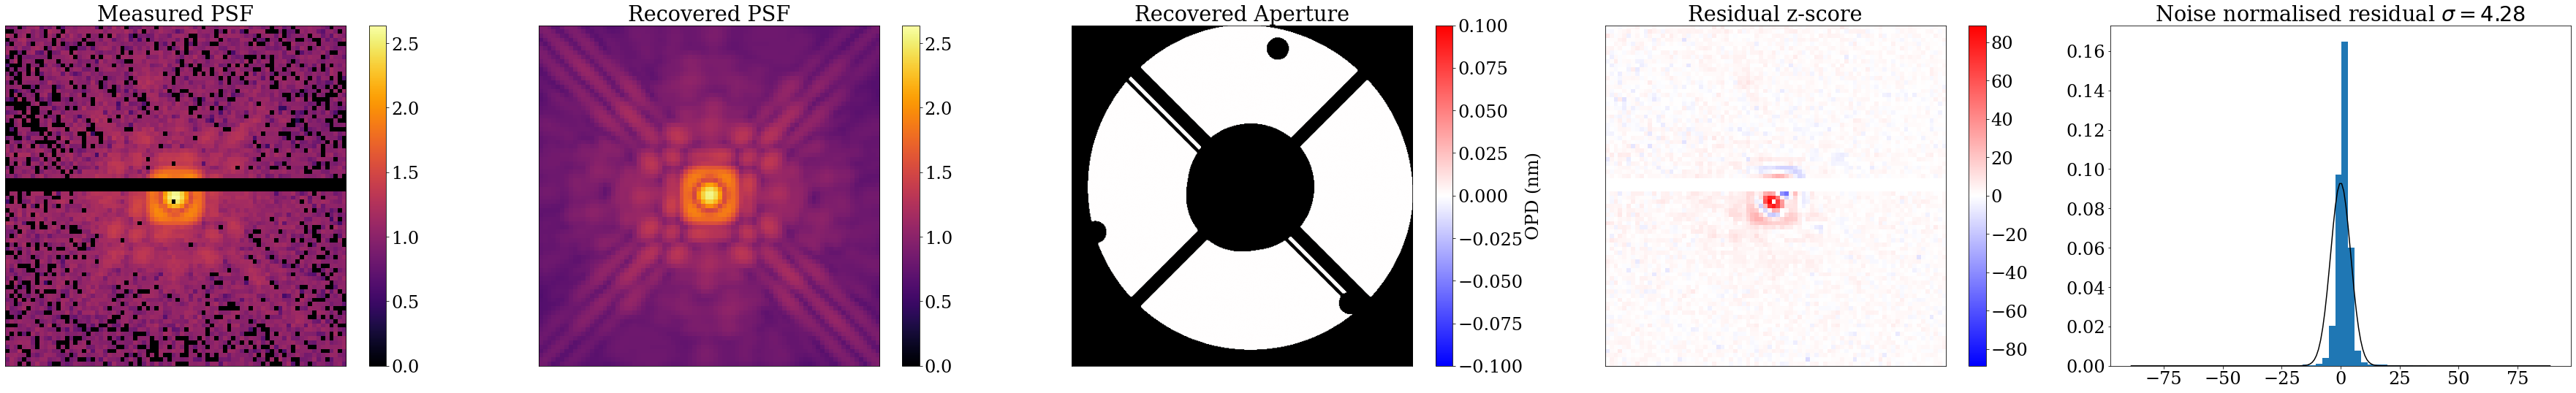

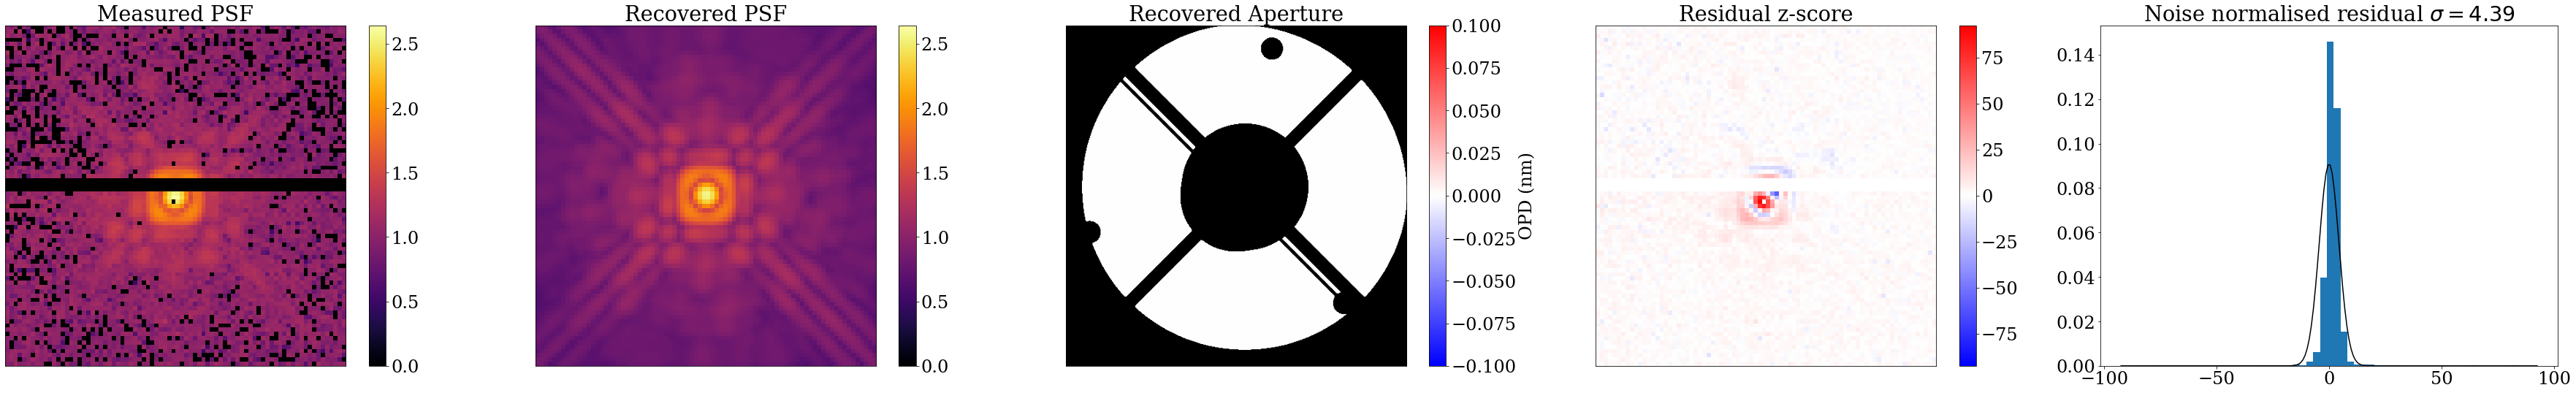

In [7]:
plot_comparison(model_single, params, exposures_single)

In [8]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*0.5, 10),
    "bias": sgd(g*3, 20),
    "cold_mask_shift": sgd(g*0.3, 30),
    "defocus": sgd(g*0.08, 30),
    "aberrations": sgd(g*0.08, 70),

    
    # #"fnumber": sgd(g*3, 100),
    "cold_mask_shear": sgd(g*0.5, 100),

    "quadrature": sgd(g*25, 950),
}

things_start = {
    "positions": sgd(g*5, 0),
    "spectrum": sgd(g*0.2, 10),
}

groups = list(things.keys())

In [9]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [10]:
opt_params

{'positions': {'na2a04mcq': Array([0., 0.], dtype=float64),
  'na2a04mdq': Array([0., 0.], dtype=float64),
  'na2a04mhq': Array([0., 0.], dtype=float64),
  'na2a04miq': Array([0., 0.], dtype=float64),
  'na2a04mmq': Array([0., 0.], dtype=float64),
  'na2a04mnq': Array([0., 0.], dtype=float64),
  'na2a04mrq': Array([0., 0.], dtype=float64),
  'na2a04msq': Array([0., 0.], dtype=float64)},
 'spectrum': {'N581_F160W': Array([6746.25248283,    0.        ,    0.        ], dtype=float64)}}

In [11]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 20, nbatches=5)

  0%|          | 0/20 [00:00<?, ?it/s]

2.697785699792322
2.673162411182055
2.594859836631239
2.5694163922377036
2.7576603780011815
2.63799238749605
2.790222615703494
2.783970854175692


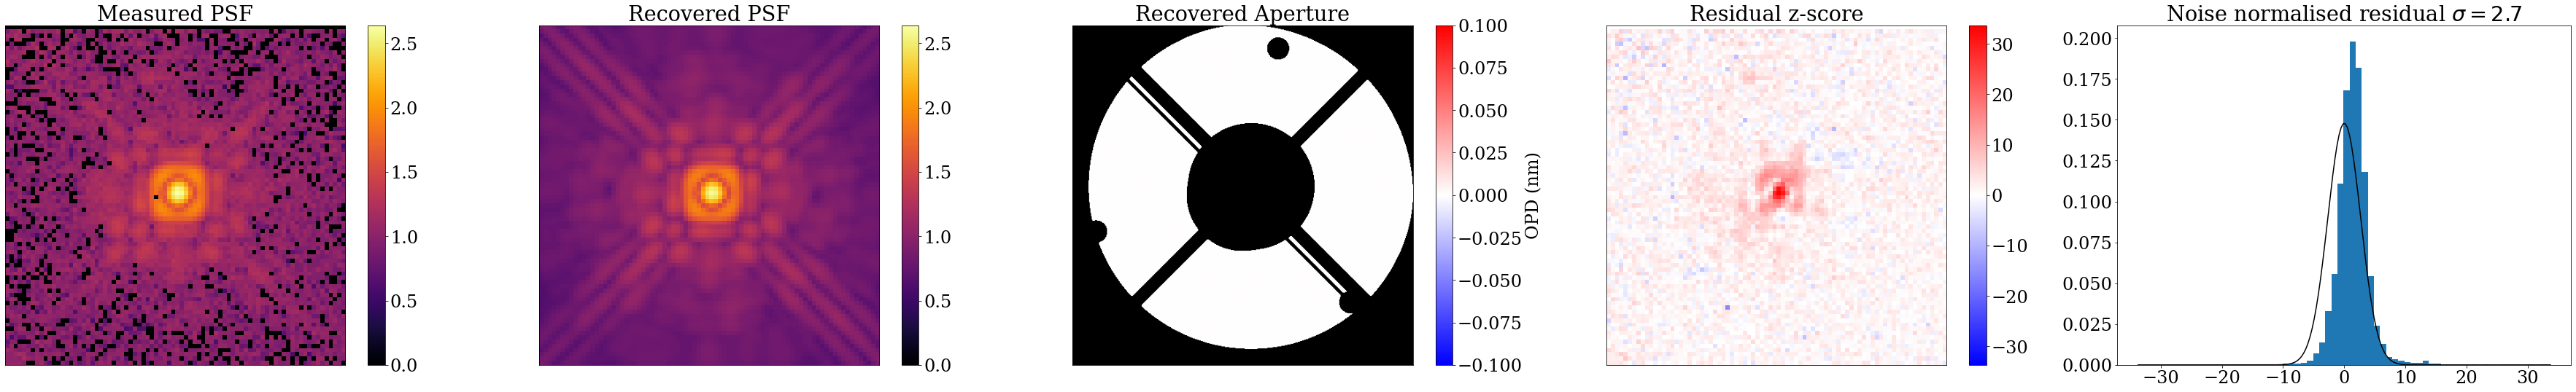

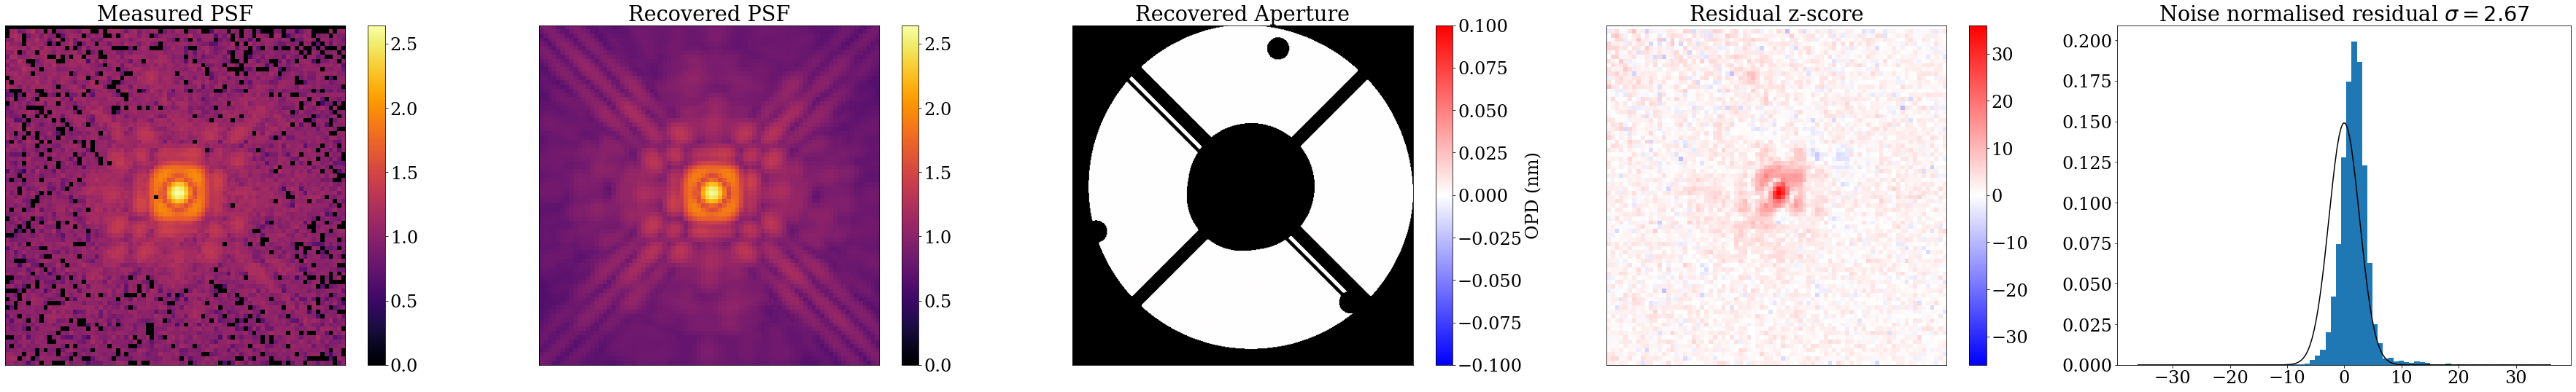

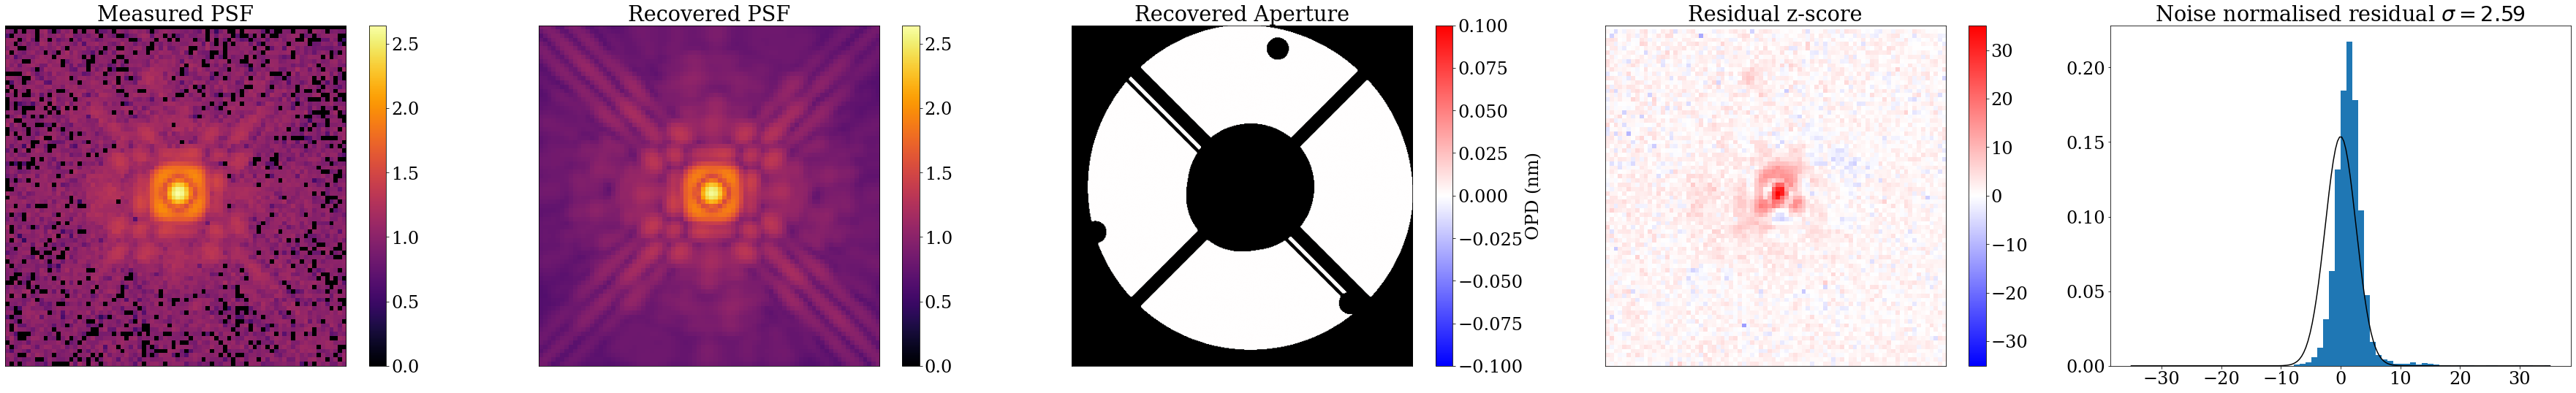

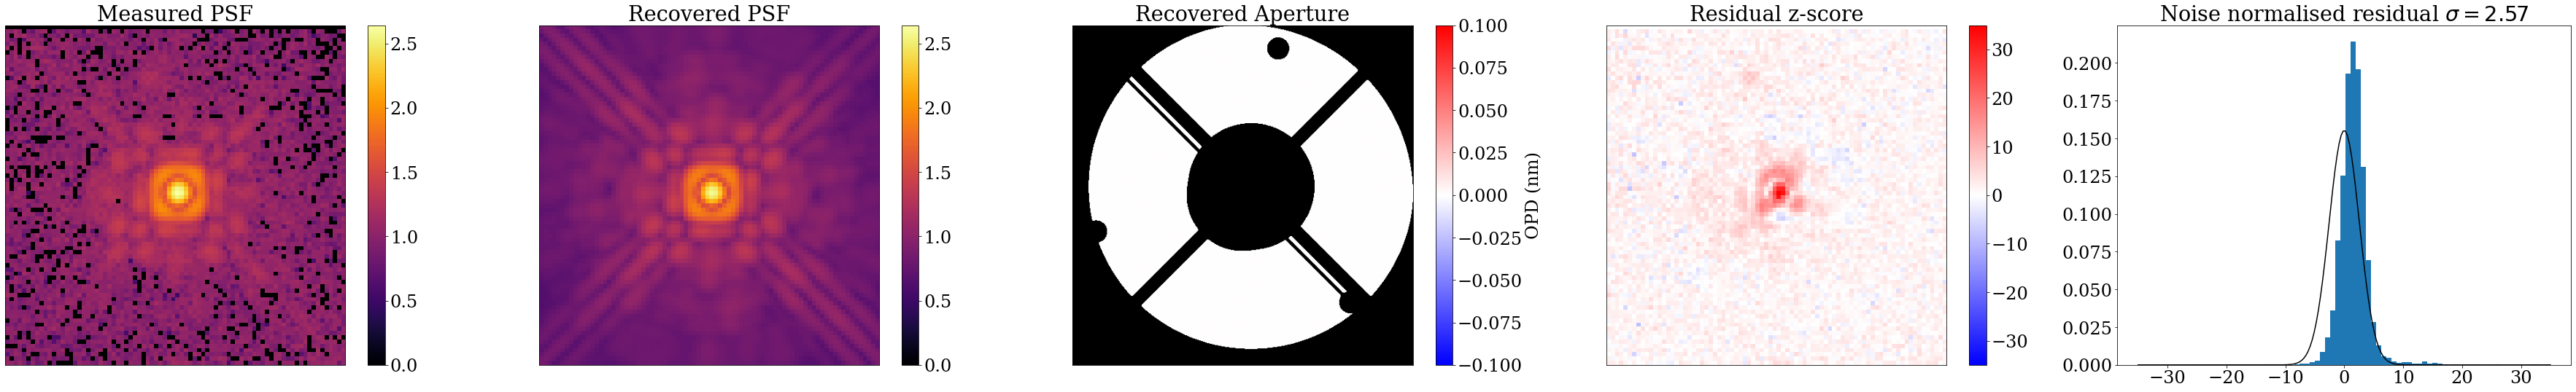

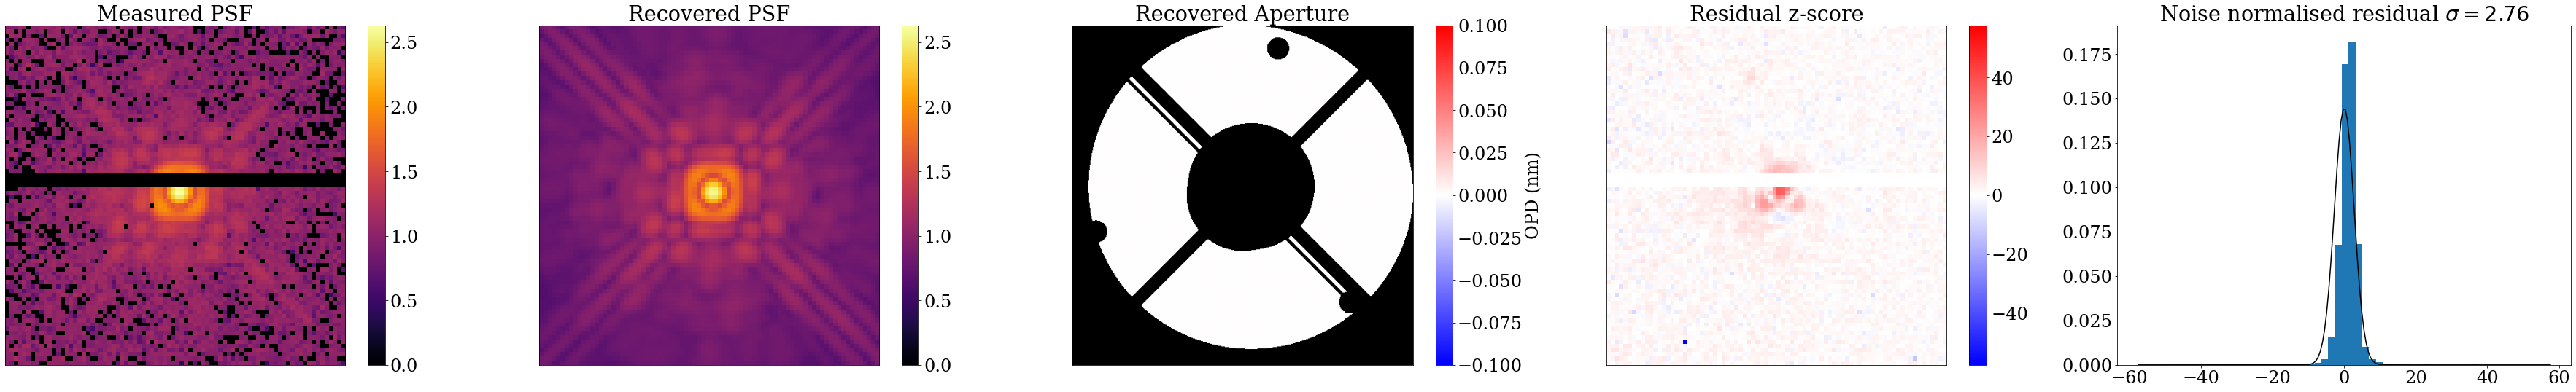

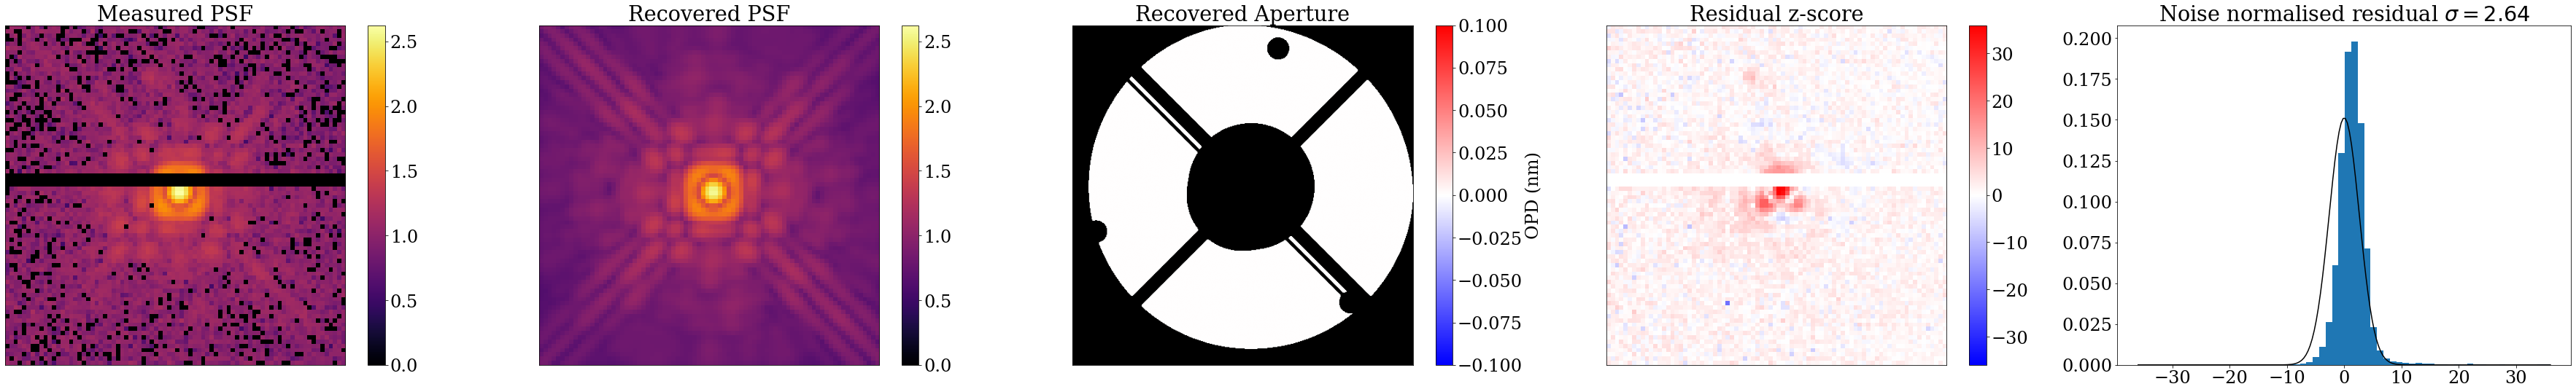

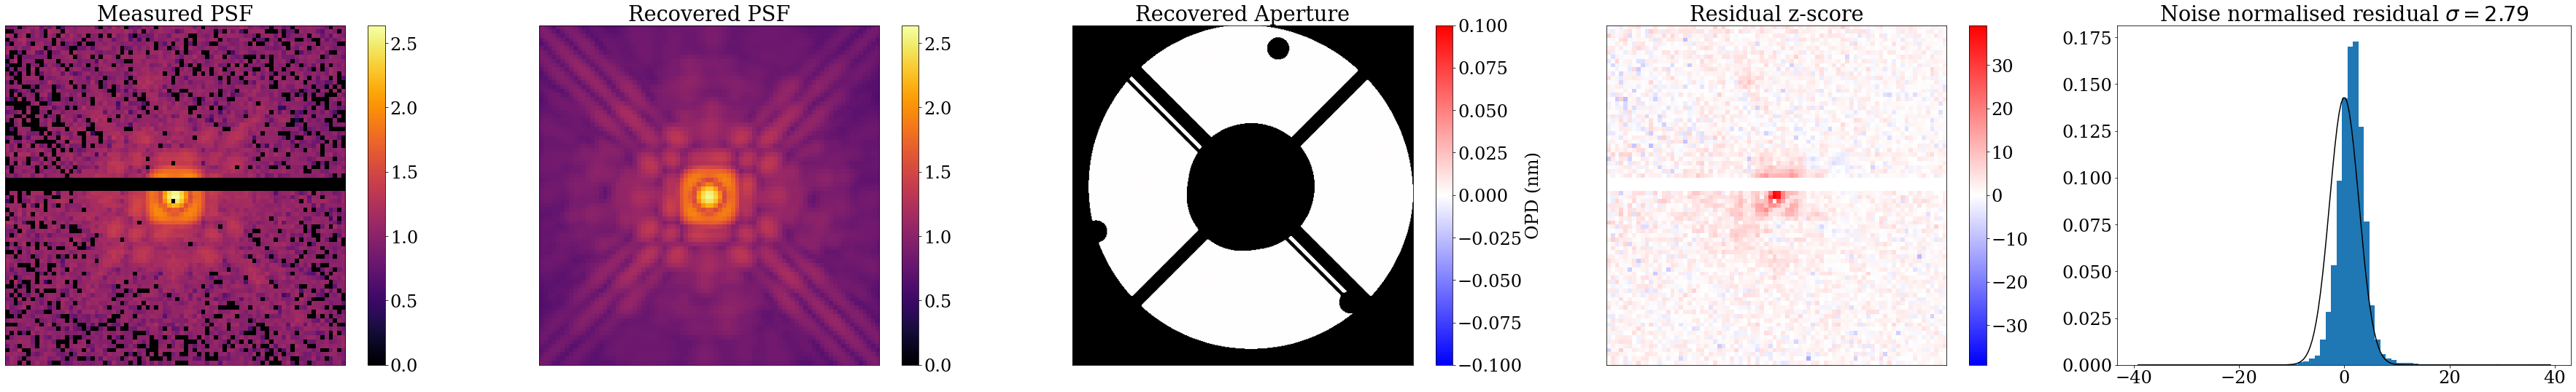

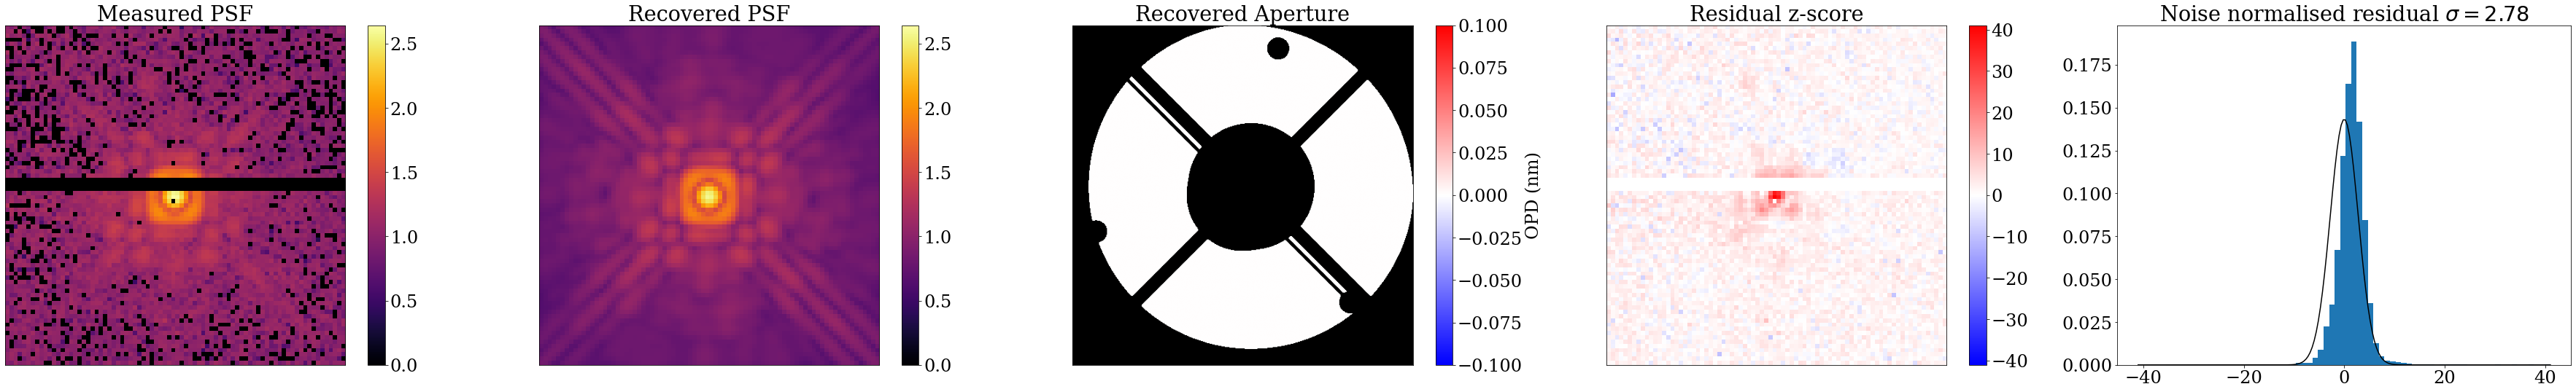

In [12]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

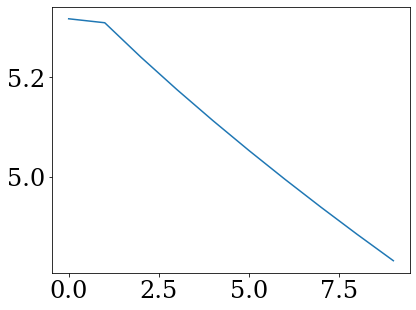

In [13]:
plt.plot(np.asarray(losses[-10:])/(len(exposures_single)*wid**2))

In [14]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [15]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=100)

  0%|          | 0/500 [00:00<?, ?it/s]

In [16]:
len(losses)

500

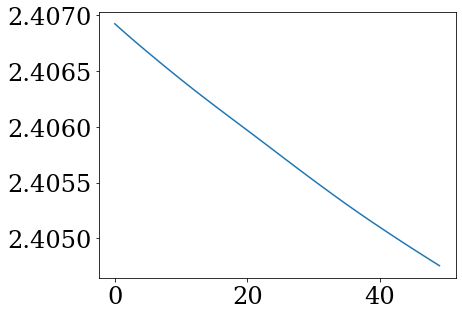

In [17]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [18]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

8
2.1358780281049277
2.1108767313159187
1.9479434665123672
1.9105250732615469
2.161241287664084
2.025236413850262
2.35570798423944
2.335631214586856


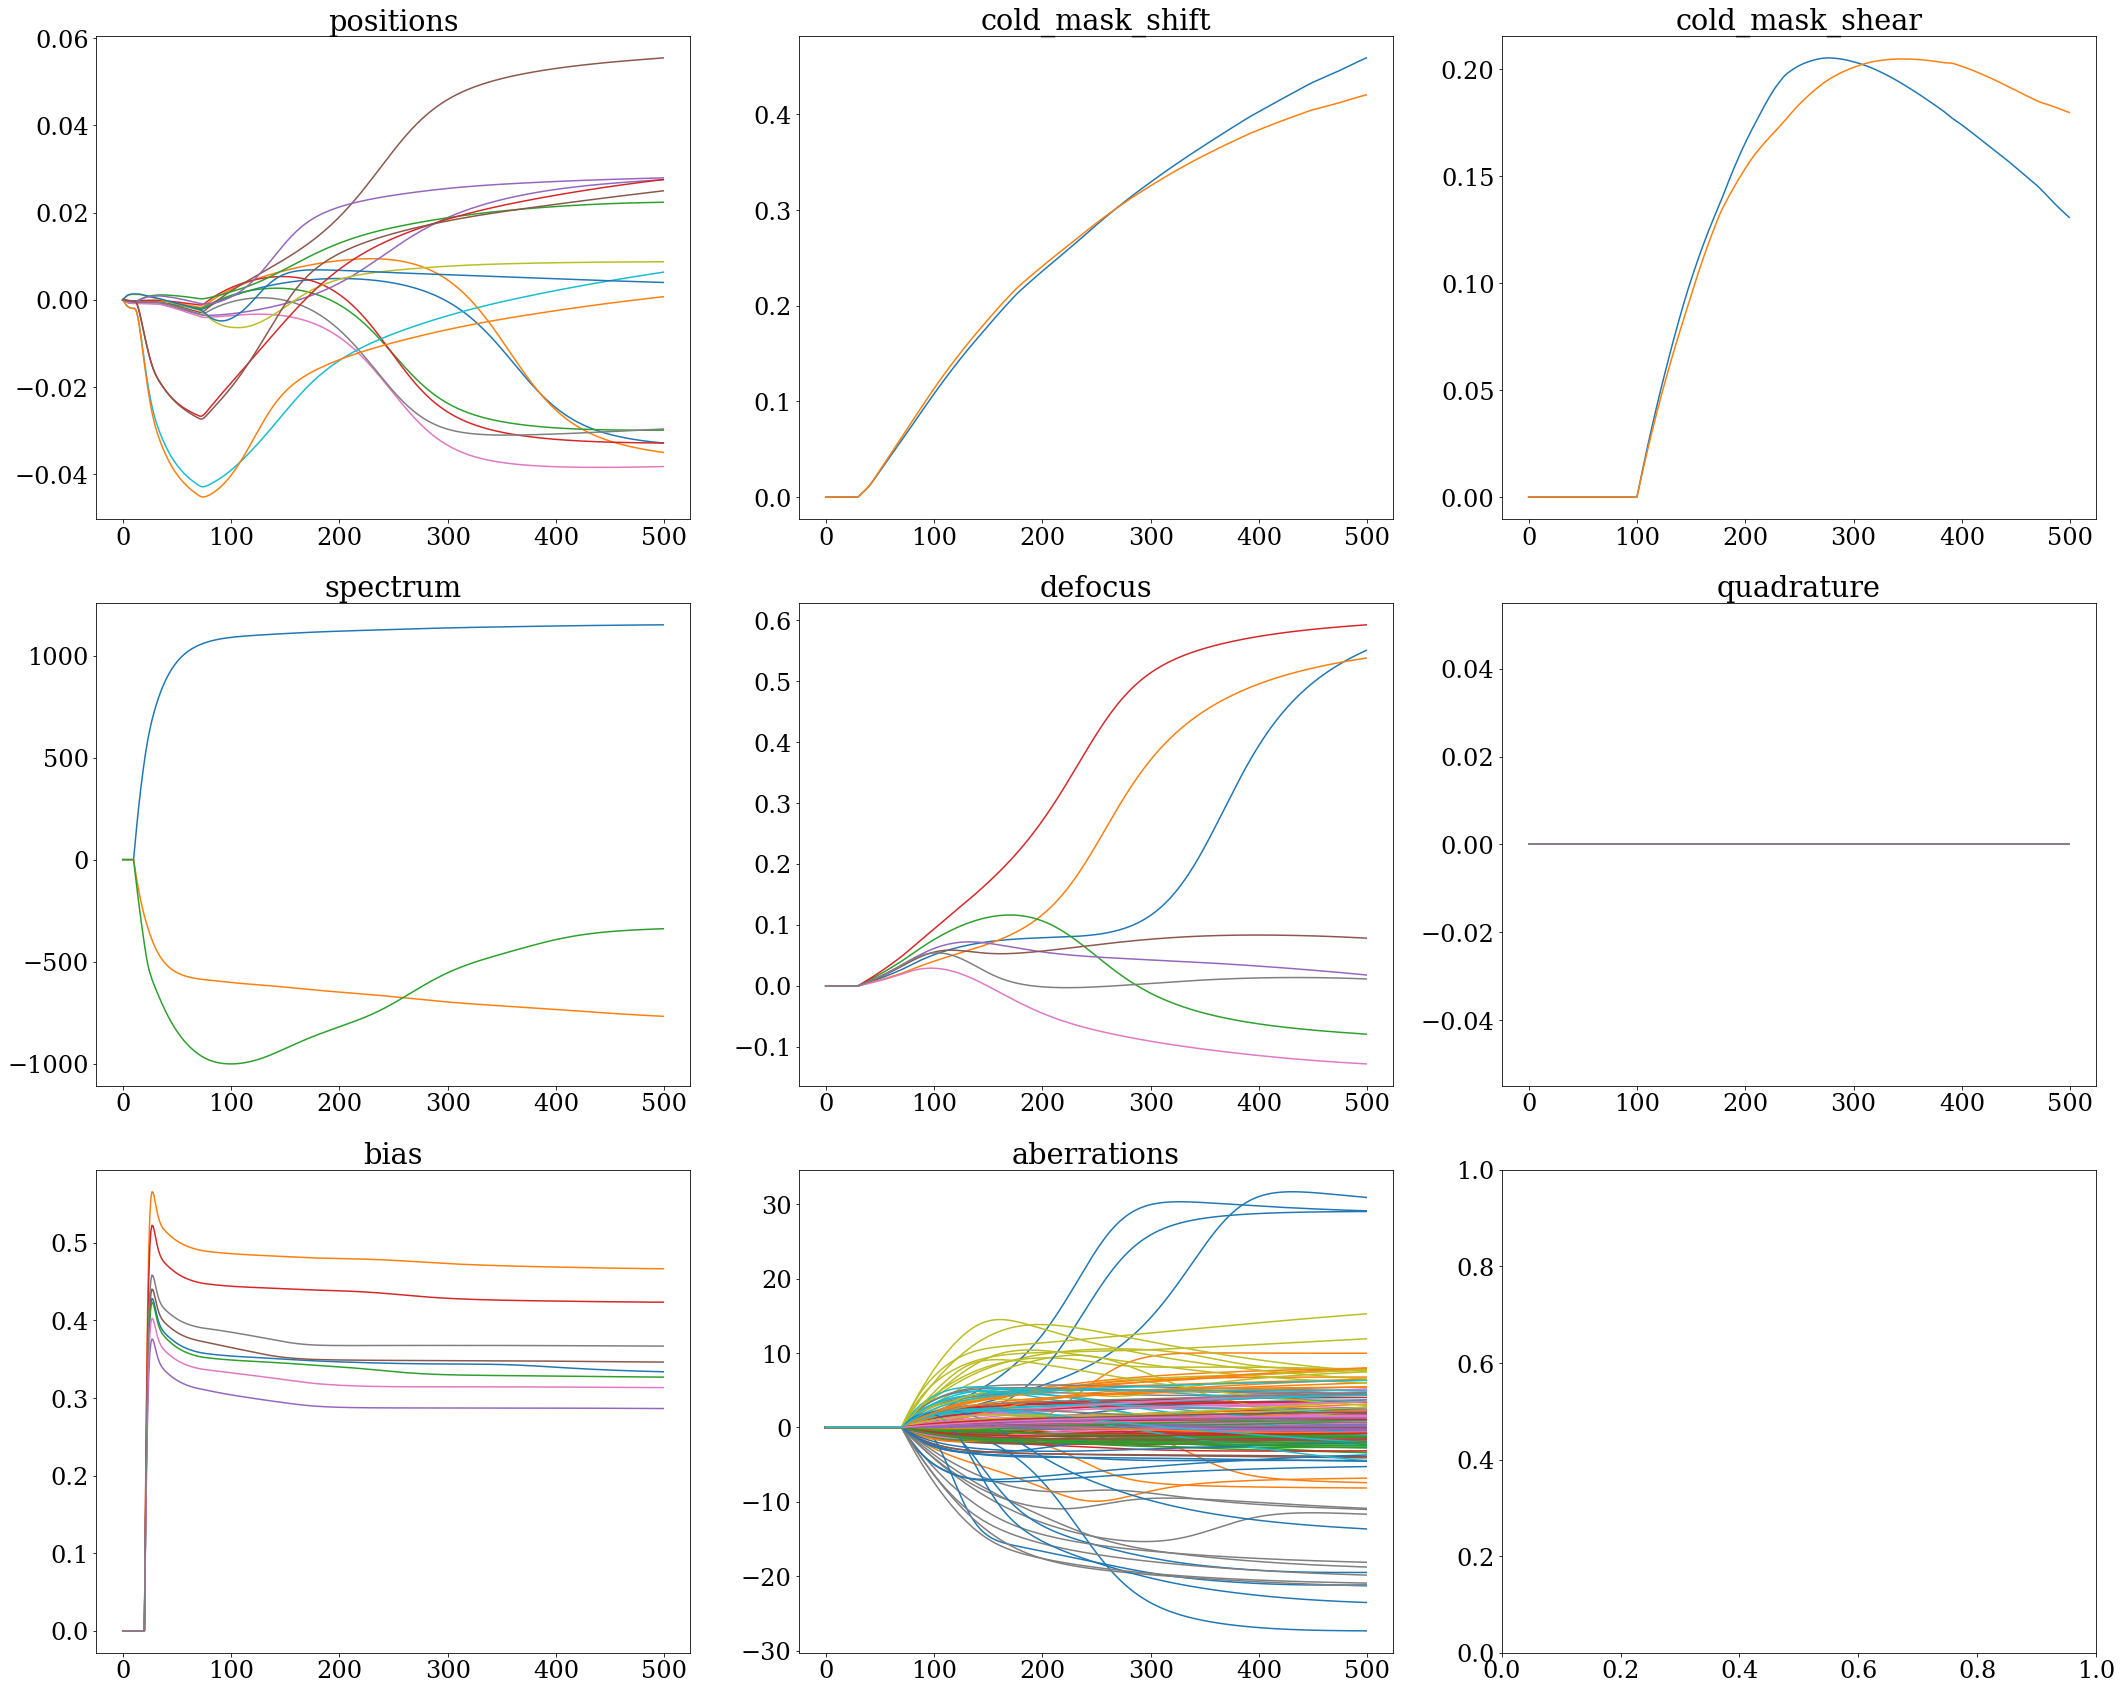

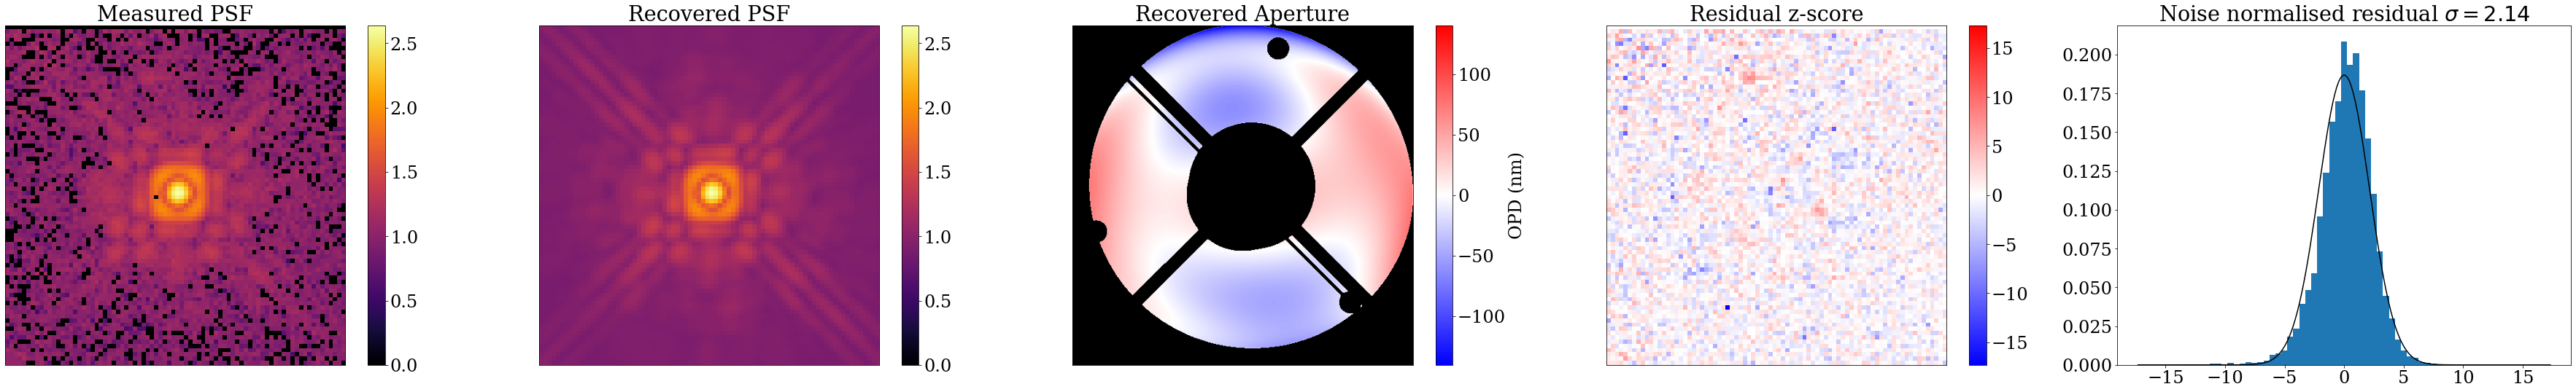

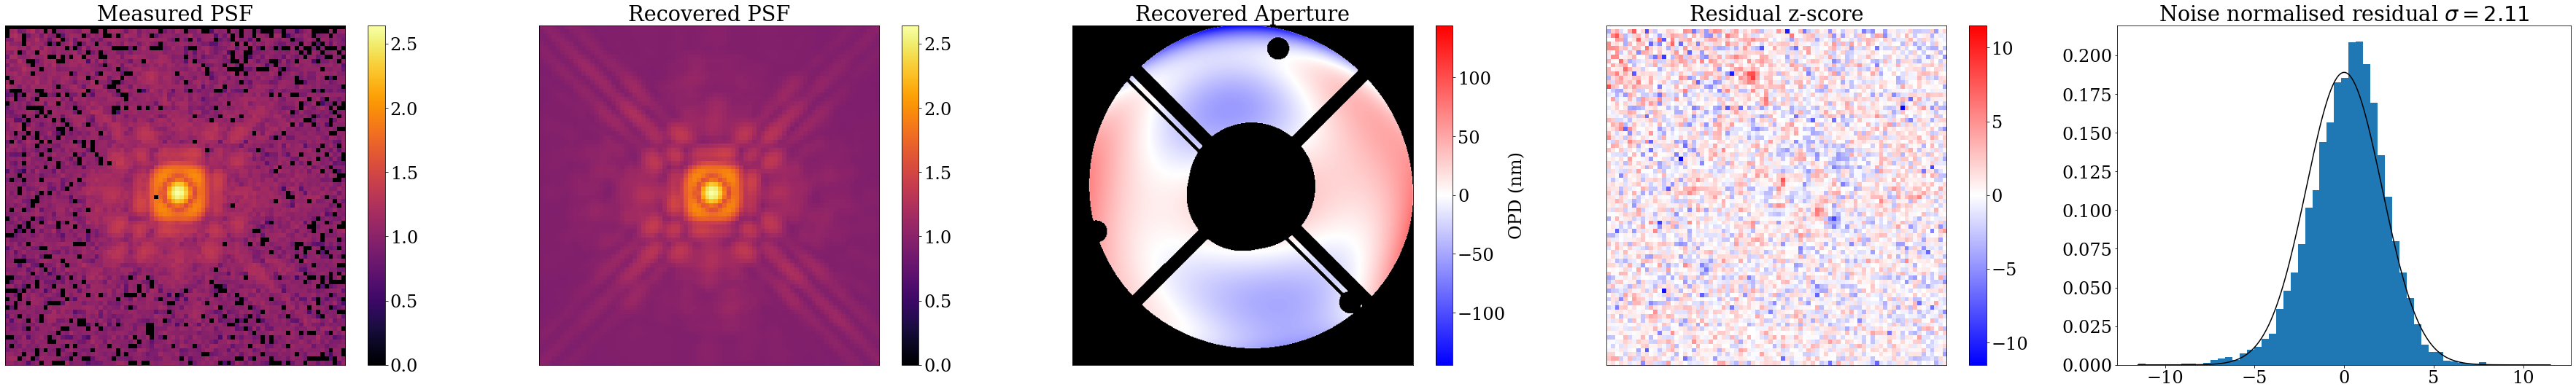

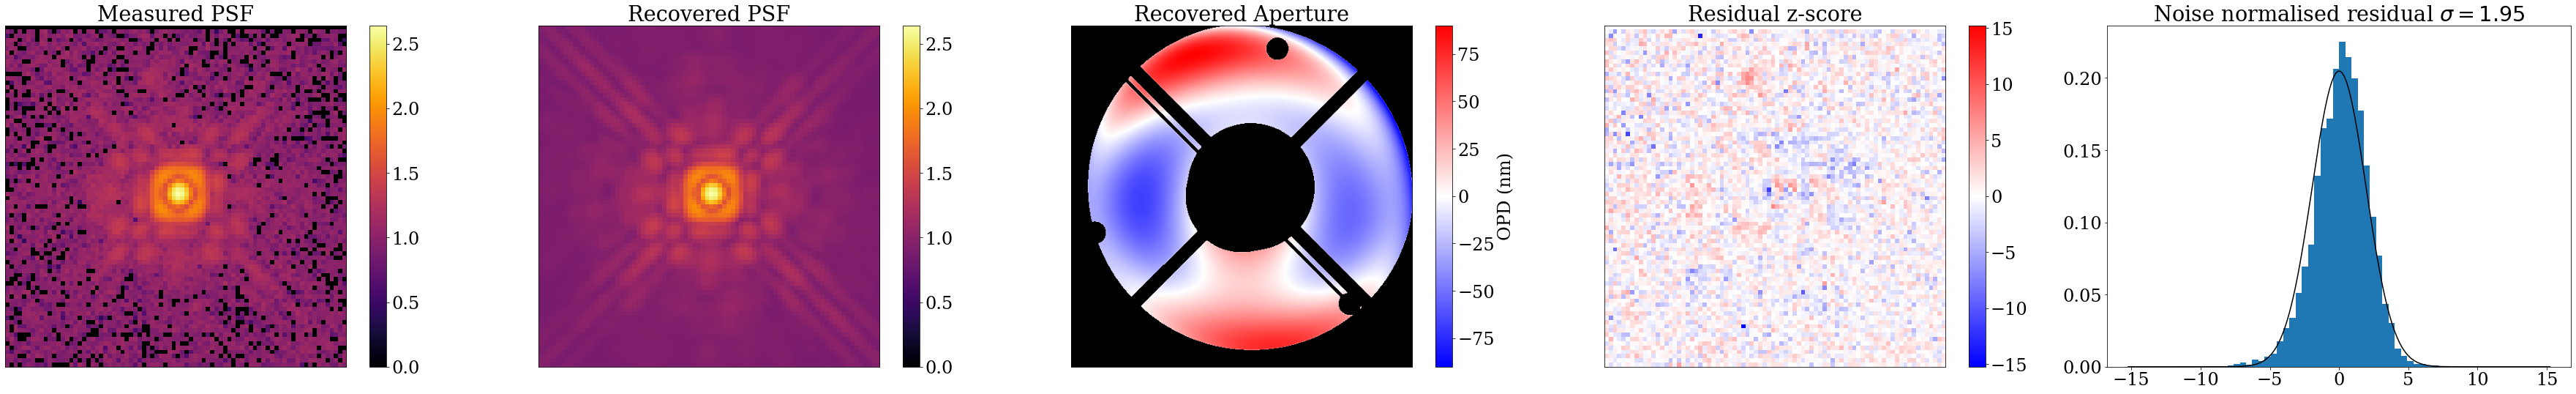

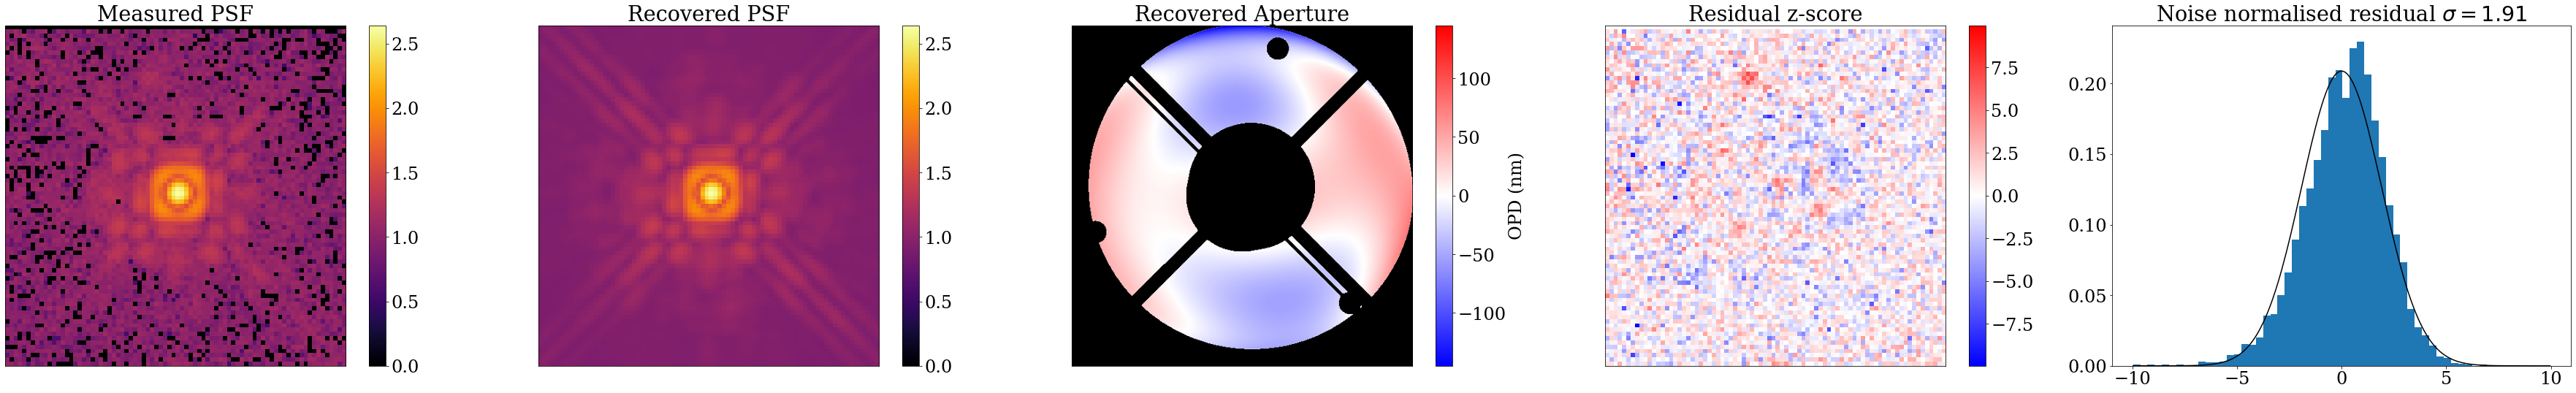

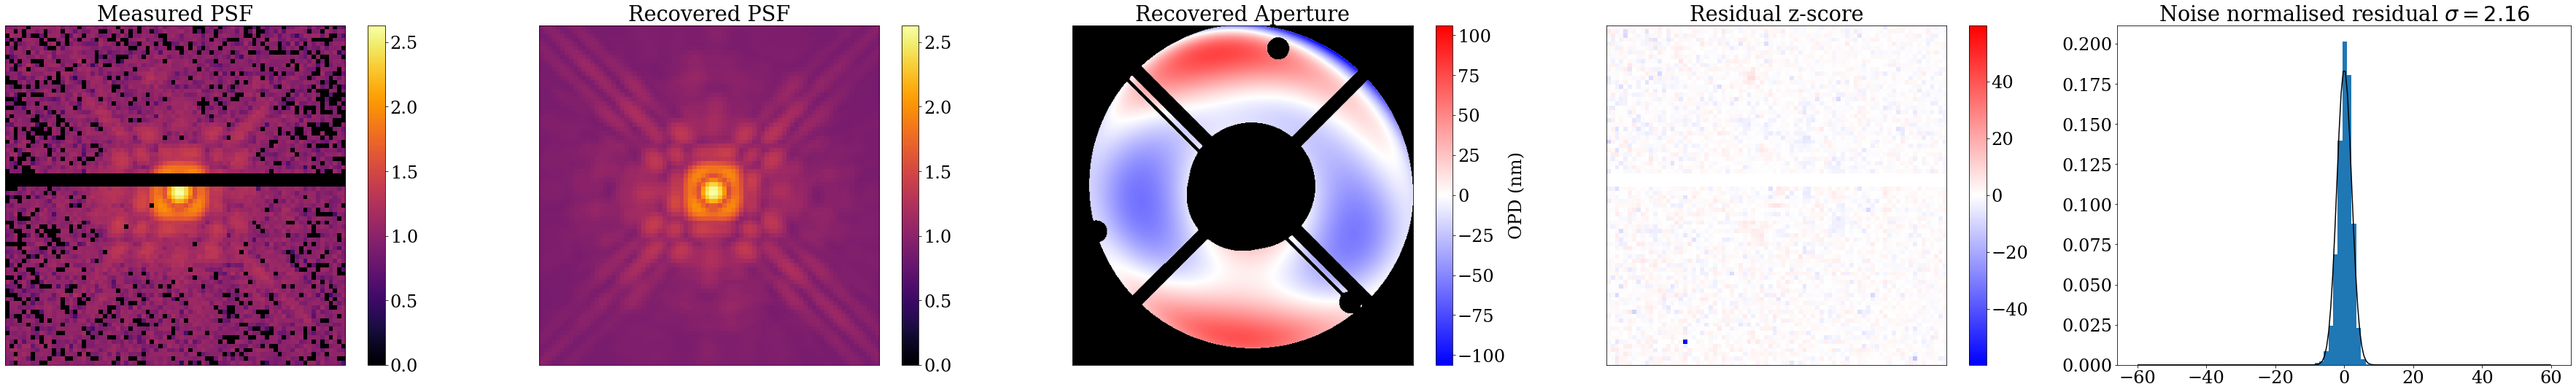

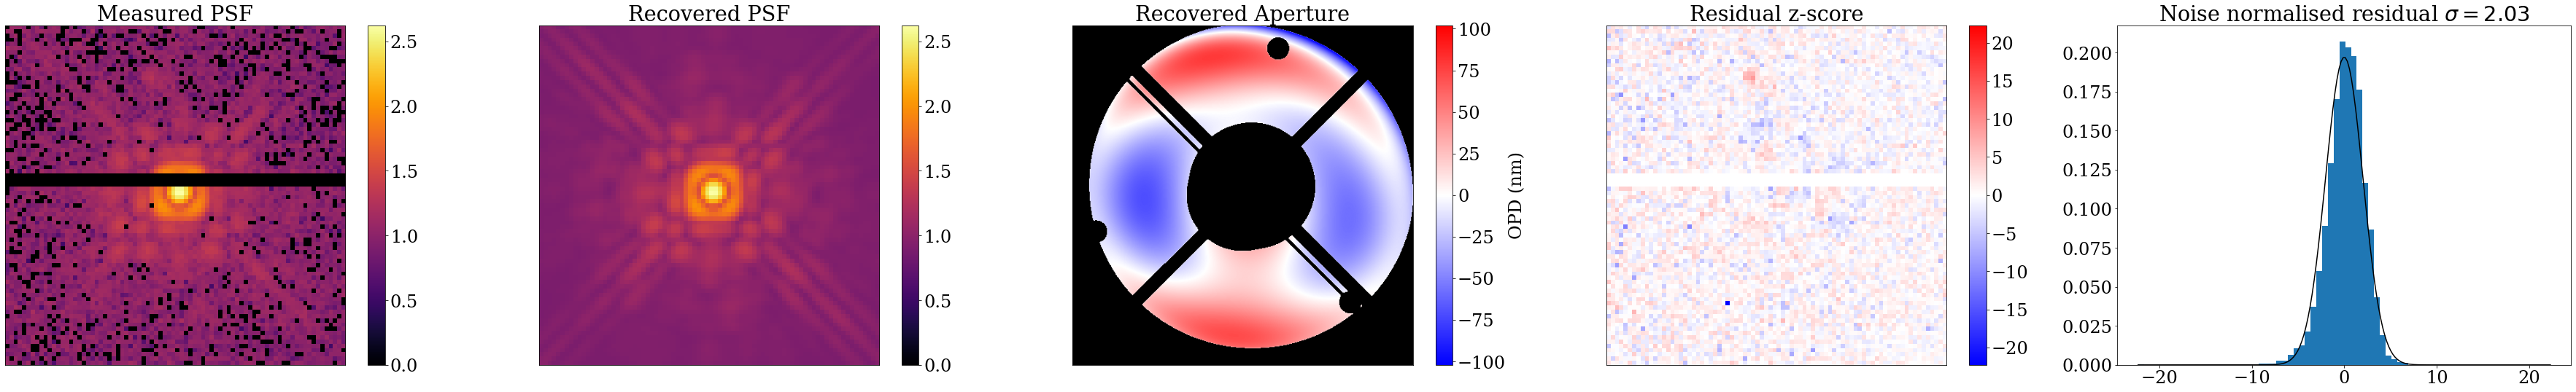

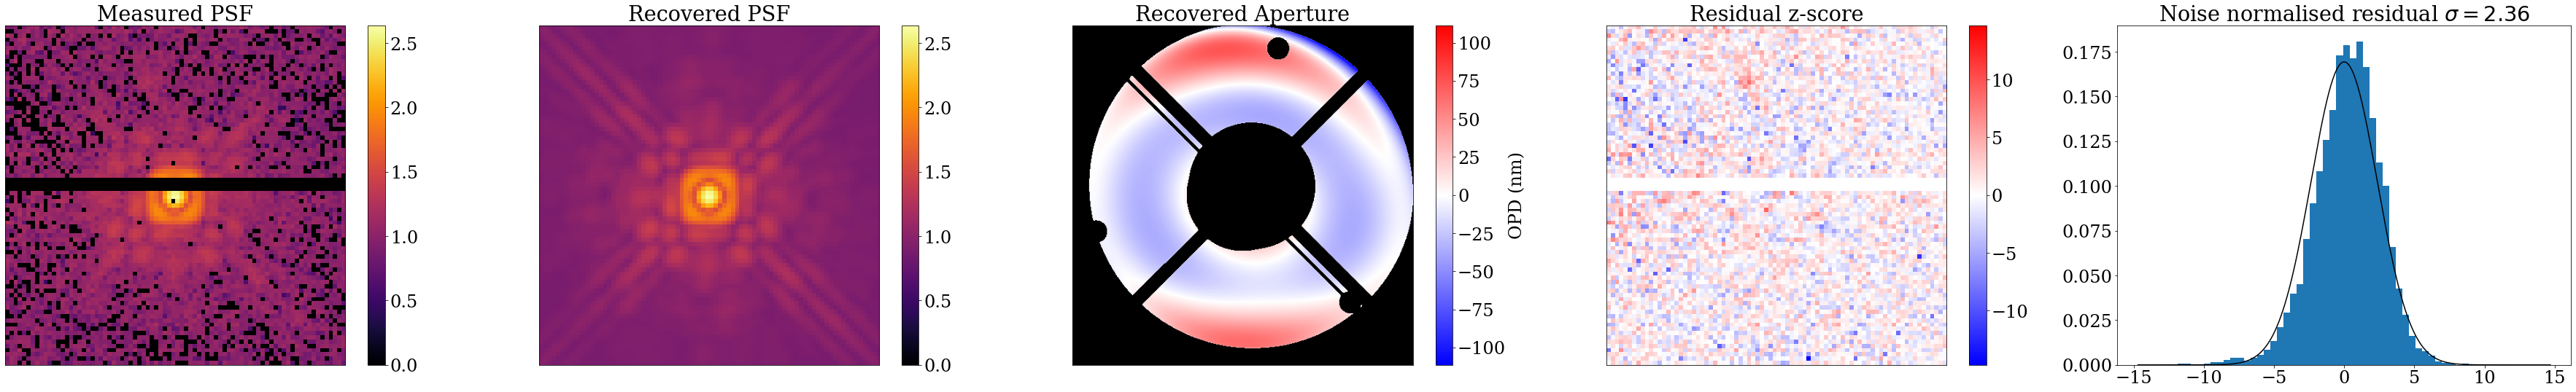

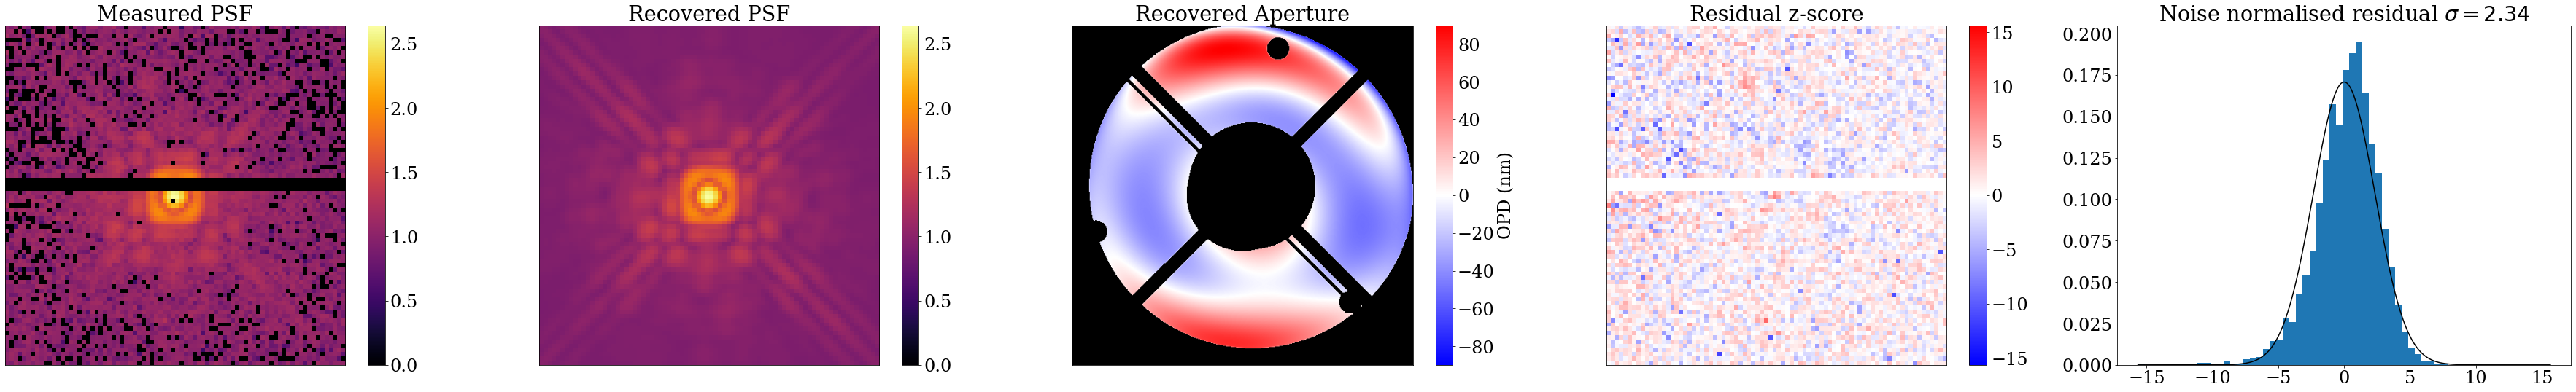

In [19]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [35]:
coadd = np.zeros((wid, wid))

model = ModelParams(params_history[-1]).inject(model_single)
for exp in exposures_single:
    fit = exp.fit(model, exp)
    resid = (exp.data - fit)/len(exposures_single)#/exp.err
    coadd = coadd + resid

In [45]:
print(exp.key)

na2a04msq


In [46]:
np.sum((fit-0.36694461))


Array(45697.61447312, dtype=float64)

In [36]:
np.nansum(exposures_single[0].data)

Array(48623.82597421, dtype=float64)

In [51]:
np.sum(coadd[60:70,30:40])/np.sum((fit-0.36694461))


Array(0.00157414, dtype=float64)

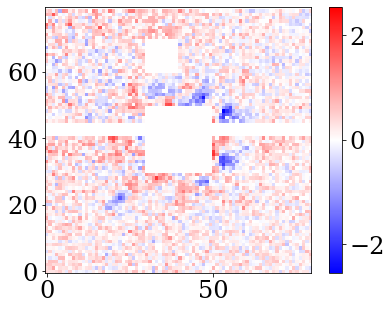

In [ ]:
resid_coadd = coadd.at[wid//2 -10 : wid//2 +10, wid//2 -10 : wid//2 +10].set(0.)#.at[60:70,30:40].set(0.)
rlim = np.nanmax(np.abs(resid_coadd))
plt.imshow(resid_coadd, cmap="bwr", vmin=-rlim, vmax=rlim)
plt.colorbar()

In [53]:
14.35+5*np.log10(2.48/100)

Array(6.3222584, dtype=float64)

In [34]:
params_history[-1]

{'aberrations': {'na2a04mcq': Array([ 30.89593325,  -7.42361498,  -1.91155121,  -1.56653796,
          -1.24695205,  -0.83594088,   2.63459476,   2.27198922,
          -0.88503343,  -0.89415635,   2.69538432,   7.71104725,
          -3.41397338,   2.36683457,   1.77895756,   1.36298165,
           1.41343667, -11.6631259 ,   7.64178369,   0.22928417],      dtype=float64),
  'na2a04mdq': Array([ 29.09107251,  -8.13942691,  -1.93499803,  -1.34546429,
          -1.12349536,  -0.53175521,   3.64707695,   2.4187201 ,
           0.90967215,   0.43663097,   3.67502462,   7.94450671,
          -3.34699463,   1.85097746,   1.19450093,   1.89925932,
           1.59475123, -10.87522841,   7.82954027,   0.2241343 ],      dtype=float64),
  'na2a04mhq': Array([-27.32979104,   9.96223358,  -0.86755332,  -3.14625865,
          -0.09734178,  -2.10601498,   5.17736048,   4.61669171,
           7.72442756,   0.24310979,  -4.44092528,   6.43446593,
          -2.27713518,   3.36533881,   0.63413286,  -0.86

In [20]:
stop

NameError: name 'stop' is not defined

In [ ]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single, project=True, diag=True)

In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-21.78422657,   4.98009145,  -4.8989261 ,   0.22039793,
          -1.82099966,  -2.61291491,   9.10335896,   2.23127227,
          -7.63674816,  -2.94186175,   1.0464546 ,  10.33250122,
          -8.85550859,   0.19730882,   3.12158659,   0.22200545,
           0.22197802,   2.95191057,   4.95551814,   1.96787313],      dtype=float64),
  'n9nk29d1q': Array([ 10.04052166,  -4.37864324, -12.80337046,   2.56240546,
          -1.26633006, -10.21009709,  13.00970406,  -0.44056352,
          -1.17462655,  -1.04086771,  -1.54358516,  11.79638315,
          -7.43133222,  -0.22624065,   0.52870008,  -4.18936742,
          -2.13495435,  -2.42237045,  -6.52431195,  -0.60037513],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(0.03408555, dtype=float64),
  'n9nk29d1q': Array(0.02910176, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.23954821, -0.32932549], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.53162977, 5.95762825], dtype=float6

In [ ]:
#sol.stats

0.999992783078457
0.9998770587959146


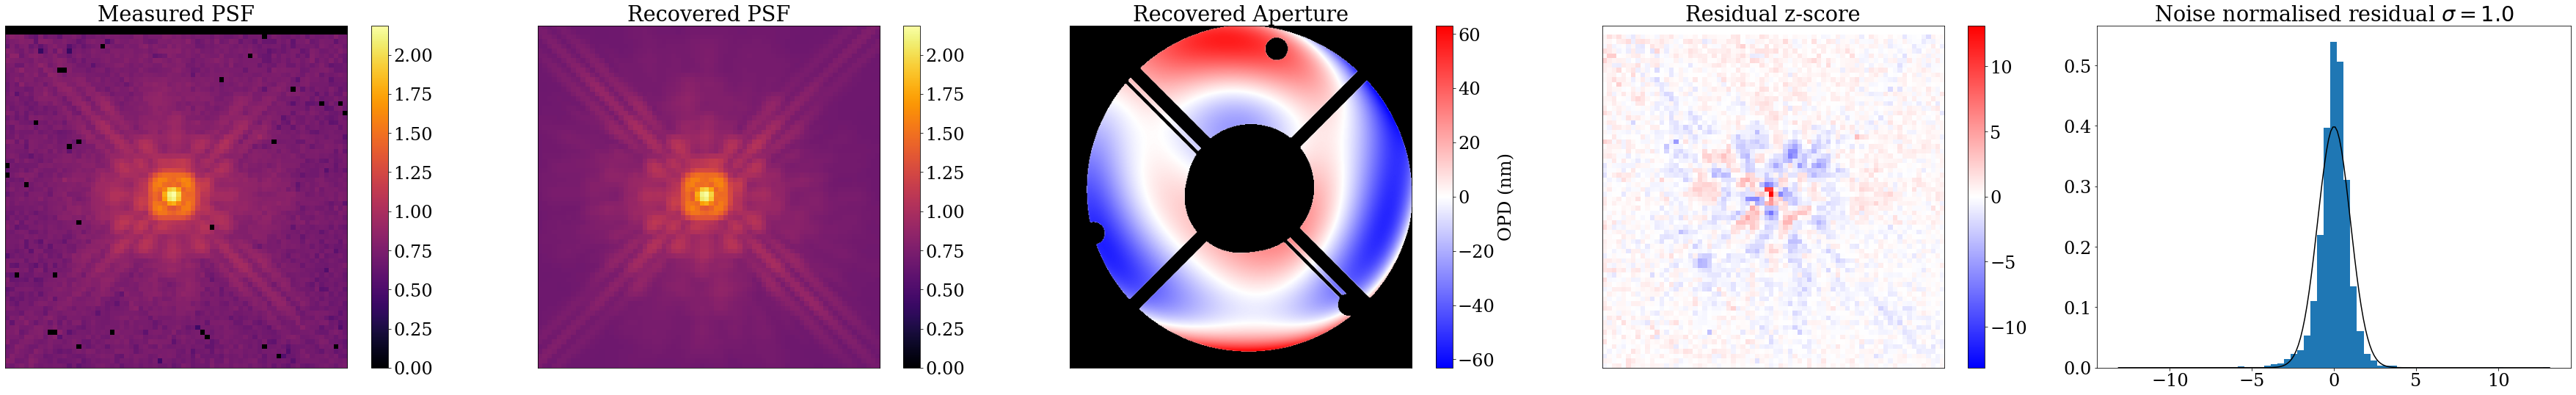

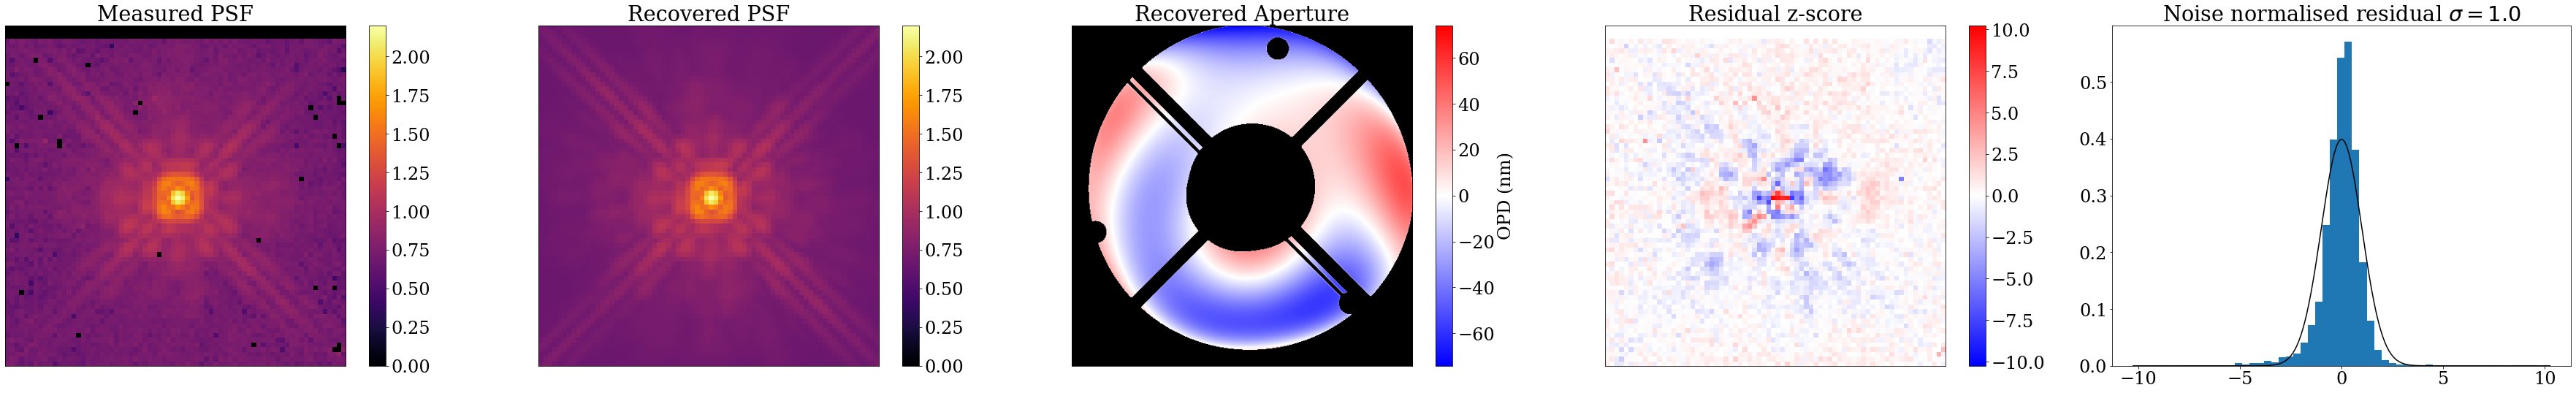

In [ ]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single, quadrature=True)

In [ ]:
# calculate spectrum

In [ ]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-21.78422657,   4.98009145,  -4.8989261 ,   0.22039793,
          -1.82099966,  -2.61291491,   9.10335896,   2.23127227,
          -7.63674816,  -2.94186175,   1.0464546 ,  10.33250122,
          -8.85550859,   0.19730882,   3.12158659,   0.22200545,
           0.22197802,   2.95191057,   4.95551814,   1.96787313],      dtype=float64),
  'n9nk29d1q': Array([ 10.04052166,  -4.37864324, -12.80337046,   2.56240546,
          -1.26633006, -10.21009709,  13.00970406,  -0.44056352,
          -1.17462655,  -1.04086771,  -1.54358516,  11.79638315,
          -7.43133222,  -0.22624065,   0.52870008,  -4.18936742,
          -2.13495435,  -2.42237045,  -6.52431195,  -0.60037513],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(0.03408555, dtype=float64),
  'n9nk29d1q': Array(0.02910176, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.23954821, -0.32932549], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.53162977, 5.95762825], dtype=float6

In [ ]:
# F, unflatten = zdx.batching.hessian(f, {"spectrum":params_history[-1]["spectrum"]}, nbatches=2*len(exposures_single))

In [ ]:
f = lambda params: loss_fn(ModelParams(final_params.params|params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, final_params.params, nbatches=10)

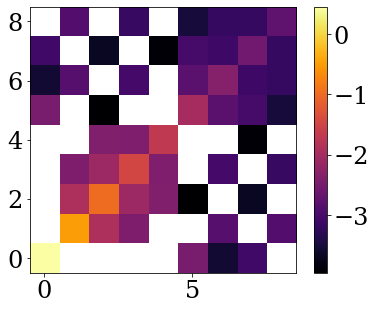

In [ ]:
plt.imshow(np.log10(F[-(npoly):, -(npoly):]))
plt.colorbar()

In [ ]:
np.linalg.cond(F[-(npoly):, -(npoly):])

Array(2004.21062278, dtype=float64)

In [ ]:
cov_f110w = np.linalg.inv(F)[-(npoly):, -(npoly):]
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


In [ ]:
final_params

ModelParams(
  params={
    'aberrations': {'n9nk29c8q': f64[20], 'n9nk29d1q': f64[20]},
    'bias': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'cold_mask_shear': {'global': f64[2]},
    'cold_mask_shift': {'global': f64[2]},
    'defocus': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'positions': {'n9nk29c8q': f64[2], 'n9nk29d1q': f64[2]},
    'quadrature': {'n9nk29c8q': f64[], 'n9nk29d1q': f64[]},
    'spectrum': {'U20581_F110W': f64[9]}
  }
)

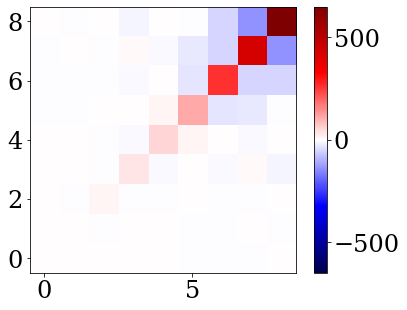

In [ ]:
plt.imshow(cov_f110w, cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


In [ ]:
cov2_f110w = np.linalg.inv(F)

In [ ]:
np.sqrt(np.diag(cov_f110w))

Array([ 0.61151991,  2.01199748,  3.4208294 ,  5.62409462,  7.25208674,
       10.39670901, 16.09722043, 20.64314021, 25.47343414], dtype=float64)

In [ ]:
final_params.get("spectrum.U20581_F110W")[:]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([ 1.15072196e+03,  3.07189213e+01,  1.21368807e+01, -8.56824993e+00,
        4.73413092e+00,  5.12562659e+00, -3.99087350e+00, -2.11635116e-01,
       -5.52683087e-01], dtype=float64)

In [ ]:
final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(np.diag(cov2_f110w[-(npoly):, -(npoly):]))

Array([1150.72195947,  349.74665695,  205.70724585,  125.12047562,
         97.03267759,   67.68385973,   43.71496293,   34.08829214,
         27.62444161], dtype=float64)

In [ ]:
print("mode covariances")
print(final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(np.diag(cov_f110w)))

print(final_params.get("spectrum.U20581_F110W")[0]*np.sqrt(np.real(np.linalg.eigvals(F[-(npoly):, -(npoly):]))))


mode covariances
[1150.72195947  349.74665695  205.70724585  125.12047562   97.03267759
   67.68385973   43.71496293   34.08829214   27.62444161]
[1185.18408158  392.37562742  227.14395562  130.74186453   99.66897909
   72.03331162   26.47366872   35.52509328   46.40752886]


In [ ]:
c0 = final_params.get("spectrum.U20581_F110W")[0]
np.max((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]),axis=1)

Array([0.00086902, 0.00451095, 0.01086375, 0.02074276, 0.02518901,
       0.04186708, 0.05864305, 0.07295261, 0.1338618 ], dtype=float64)

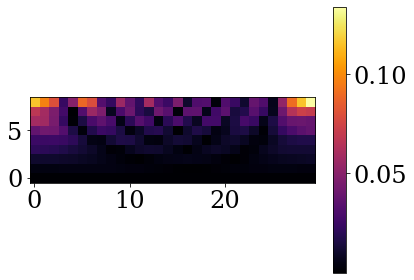

In [ ]:
plt.imshow((np.sqrt(np.diag(cov_f110w)) * np.abs(spectrum_basis)).T/(c0*spectrum_basis[:,0]))
plt.colorbar()

In [ ]:
# final_params.get("spectrum.U20581_F110W")[0]/np.sqrt(vals)

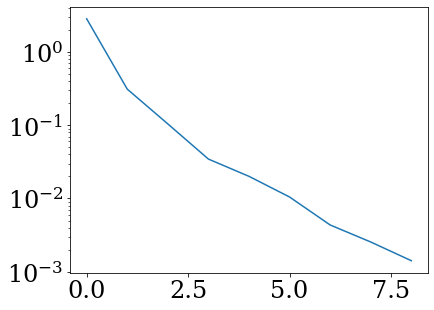

In [ ]:
vals, vects = np.linalg.eig(F[-(npoly):, -(npoly):])#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [ ]:
wavels, bandpass = calc_throughput("F110W", nwavels=nwavels*2)

In [ ]:
#final_params = ModelParams(params_history[-1])

In [ ]:
fname = "2M1439.fits"
data = fits.getdata(fname, ext=0).astype(np.float32)

In [ ]:
cov_f110w.shape

(9, 9)

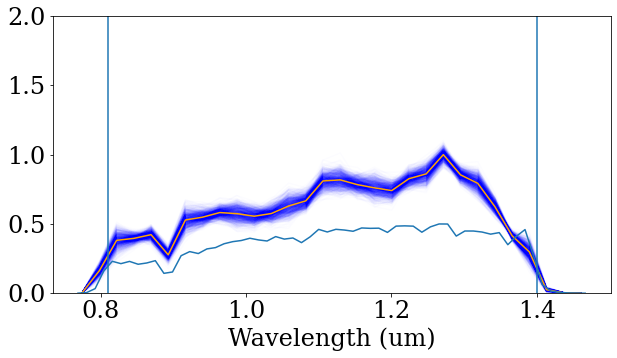

In [ ]:
plt.figure(figsize=(10,5))


wv, filt = calc_throughput("F110W", nwavels=nwavels)

spec = PreCombinedBasisSpectrum(wv, final_params.get("spectrum.U20581_F110W"), spectrum_basis)

sp = spec.spec_weights()/spec.flux/(wv*1e6)#*spec.proper_flux()/(wv*1e6)

smax = np.max(sp)

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.U20581_F110W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wv, coeffs, spectrum_basis)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
#plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))
plt.plot(wavels*1e6, bandpass/np.max(bandpass)*0.5)

plt.xlabel("Wavelength (um)")
plt.ylim(0,2)
plt.axvline(0.81)
plt.axvline(1.4)

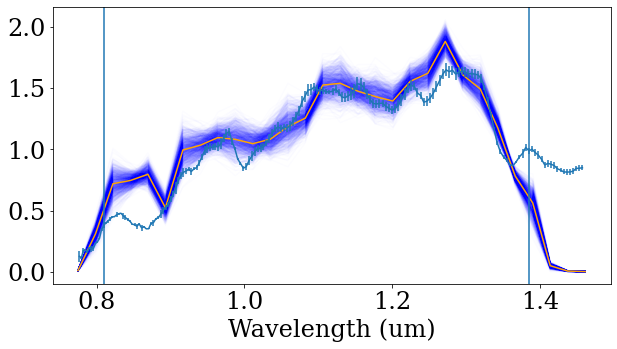

In [ ]:
plt.figure(figsize=(10,5))

wv, filt = calc_throughput("F110W", nwavels=nwavels)


spec = PreCombinedBasisSpectrum(wv, final_params.get("spectrum.U20581_F110W"), spectrum_basis)

sp = spec.spec_weights()/spec.flux/(wv*1e6)

smax = np.mean(sp)*1.0

sp = sp/smax

plt.plot(wv*1e6, sp, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.U20581_F110W"), (cov_f110w))
    spec = PreCombinedBasisSpectrum(wv, coeffs, spectrum_basis)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux/(wv*1e6)/smax, color='b', alpha=0.01, zorder=0)
    # try 32nd and 68th percentile plot


wv_range = (data[0]*1e-6 > np.min(wv)) & (data[0]*1e-6 < np.max(wv))
plt.errorbar(data[0][wv_range], data[1][wv_range]/np.mean(data[1][wv_range]), data[2][wv_range]/np.mean(data[1][wv_range]))

plt.xlabel("Wavelength (um)")
plt.axvline(0.81)
plt.axvline(1.385)

In [ ]:
final_params.params

{'aberrations': {'n9nk29c8q': Array([-21.78422657,   4.98009145,  -4.8989261 ,   0.22039793,
          -1.82099966,  -2.61291491,   9.10335896,   2.23127227,
          -7.63674816,  -2.94186175,   1.0464546 ,  10.33250122,
          -8.85550859,   0.19730882,   3.12158659,   0.22200545,
           0.22197802,   2.95191057,   4.95551814,   1.96787313],      dtype=float64),
  'n9nk29d1q': Array([ 10.04052166,  -4.37864324, -12.80337046,   2.56240546,
          -1.26633006, -10.21009709,  13.00970406,  -0.44056352,
          -1.17462655,  -1.04086771,  -1.54358516,  11.79638315,
          -7.43133222,  -0.22624065,   0.52870008,  -4.18936742,
          -2.13495435,  -2.42237045,  -6.52431195,  -0.60037513],      dtype=float64)},
 'bias': {'n9nk29c8q': Array(0.03408555, dtype=float64),
  'n9nk29d1q': Array(0.02910176, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.23954821, -0.32932549], dtype=float64)},
 'cold_mask_shift': {'global': Array([6.53162977, 5.95762825], dtype=float6

In [ ]:
plt.figure(figsize=(10,10))

nw = 355
wv, filt = calc_throughput("F110W", nwavels=nw)
big_basis = big_basis#load_spectrum_basis("F110W", nw, npoly)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.U20581_F110W"), big_basis)

sp = spec.spec_weights()/spec.flux*spec.proper_flux()#/(wv*1e6)


NameError: name 'big_basis' is not defined

<Figure size 720x720 with 0 Axes>

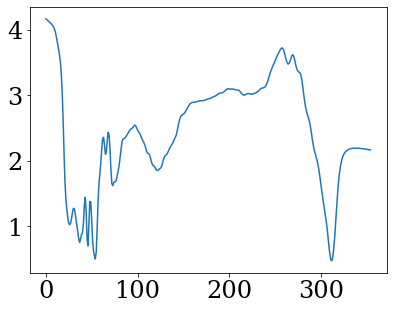

In [ ]:
plt.plot(sp/(wv*1e6))

In [ ]:
np.savez("spectrum_iterative.npz", weights=sp,params=final_params.params)

In [ ]:
sp

Array([3.18279328, 3.1810152 , 3.17923641, 3.17803104, 3.17706075,
       3.1757543 , 3.17314563, 3.16839716, 3.16052932, 3.14688611,
       3.12334953, 3.08623997, 3.0362464 , 2.98123191, 2.92630612,
       2.86312016, 2.77321621, 2.62980854, 2.3980248 , 2.05723679,
       1.65512804, 1.31985557, 1.12750664, 1.01127633, 0.91027439,
       0.84730677, 0.83271403, 0.85234721, 0.90802222, 0.98590994,
       1.04512778, 1.04796032, 0.9900375 , 0.90619229, 0.83014884,
       0.75247933, 0.66162683, 0.62729343, 0.68464065, 0.73716648,
       0.75579372, 0.87930885, 1.1130702 , 1.22469878, 1.04147272,
       0.68213879, 0.59632015, 0.90738725, 1.18363905, 1.18183832,
       0.94850669, 0.67830392, 0.5343169 , 0.47616263, 0.43429875,
       0.53030805, 0.84997352, 1.21228153, 1.4547918 , 1.59781324,
       1.74707153, 1.93156214, 2.07587338, 2.09641594, 1.99299714,
       1.87472752, 1.91044227, 2.07306827, 2.18897888, 2.15546105,
       1.96480718, 1.68487487, 1.49494286, 1.47205615, 1.51560

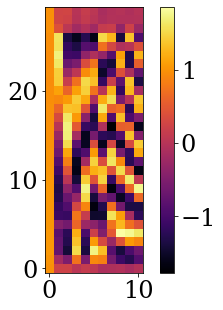

In [ ]:
plt.imshow(vects_binned[:,:20])
plt.colorbar()

(0.0, 330.0)

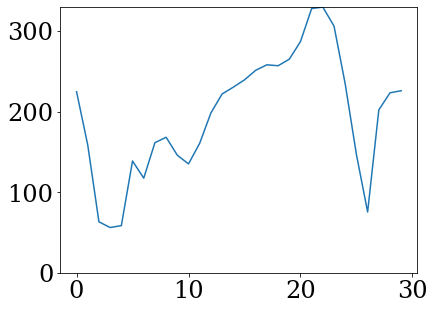

In [ ]:
plt.plot(vects_binned @ final_params.get("spectrum.U20581_F110W"))
plt.ylim(0,330)